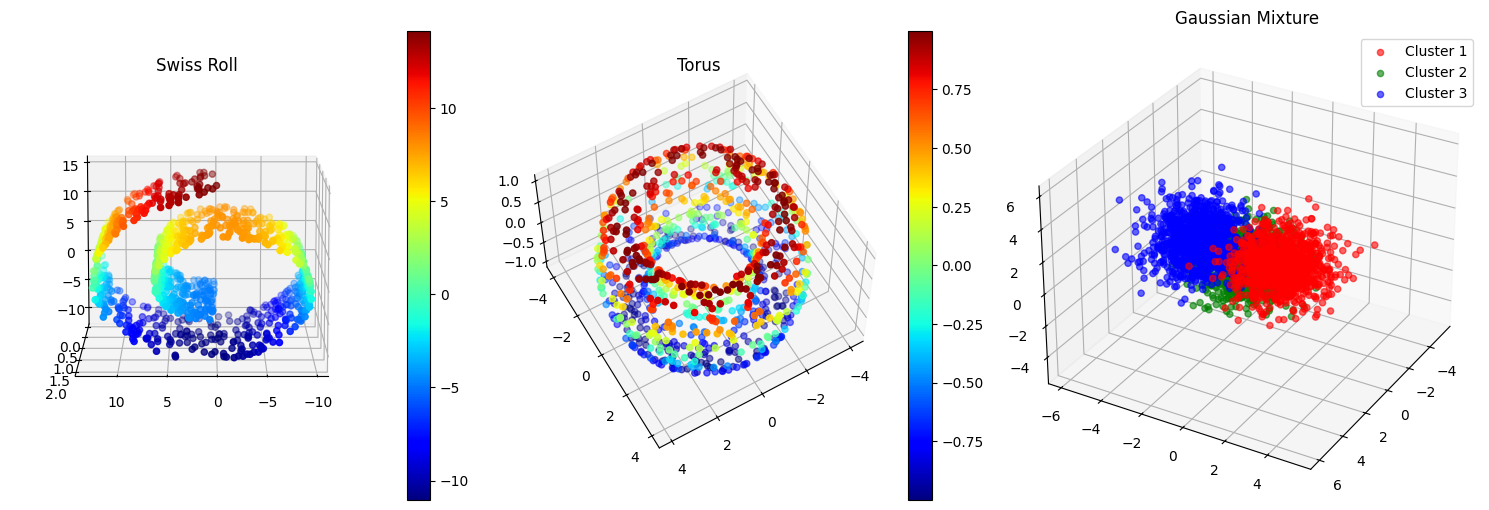

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def sample_swiss_roll(num_points, noise=0.1):
    np.random.seed(42)
    t = 1.5 * np.pi * (1 + 2 * np.random.rand(num_points))
    height = 2 * np.random.rand(num_points)
    x = t * np.cos(t)
    y = height
    z = t * np.sin(t)
    return np.column_stack((x, y, z))
#     w = noise * np.random.randn(num_points)
#     return np.column_stack((x, y, z, w))

def sample_torus(num_points, R=3, r=1):
    np.random.seed(42)
    theta = np.random.uniform(0, 2*np.pi, num_points)
    phi = np.random.uniform(0, 2*np.pi, num_points)
    x = (R + r*np.cos(phi)) * np.cos(theta)
    y = (R + r*np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)
    return np.column_stack((x, y, z))
#     w = 0.1 * np.random.randn(num_points)
#     return np.column_stack((x, y, z, w))

def sample_gaussian_mixture(num_points_per_cluster=300, std_dev=1.0):
    np.random.seed(42)
    centers = np.array([
        [2, 2, 2],
        [-2, -2, -2],
        [2, -2, 2]
    ])
    total_points = num_points_per_cluster * len(centers)
    points = np.zeros((total_points, 3))
    for i in range(len(centers)):
        start_idx = i * num_points_per_cluster
        end_idx = (i + 1) * num_points_per_cluster
        cluster_points = std_dev * np.random.randn(num_points_per_cluster, 3) + centers[i]
        points[start_idx:end_idx] = cluster_points
    return points

# Sample points
n_points = 1000
swiss_roll_points = sample_swiss_roll(n_points)
torus_points = sample_torus(n_points)
gaussian_points = sample_gaussian_mixture(n_points)  # 300 points per cluster

# Create figure
plt.figure(figsize=(15, 5))

# Plot Swiss Roll
ax1 = plt.subplot(131, projection='3d')
scatter1 = ax1.scatter(swiss_roll_points[:, 0], 
                      swiss_roll_points[:, 1], 
                      swiss_roll_points[:, 2],
                      c=swiss_roll_points[:, 2],
                      cmap='jet')
ax1.set_title('Swiss Roll')
plt.colorbar(scatter1)

# Plot Torus
ax2 = plt.subplot(132, projection='3d')
scatter2 = ax2.scatter(torus_points[:, 0],
                      torus_points[:, 1],
                      torus_points[:, 2],
                      c=torus_points[:, 2],
                      cmap='jet')
ax2.set_title('Torus')
plt.colorbar(scatter2)

# Plot Gaussian Mixture
ax3 = plt.subplot(133, projection='3d')
colors = ['r', 'g', 'b']
for i in range(3):
    start_idx = i * n_points
    end_idx = (i + 1) * n_points
    cluster_points = gaussian_points[start_idx:end_idx]
    ax3.scatter(cluster_points[:, 0],
                cluster_points[:, 1],
                cluster_points[:, 2],
                c=colors[i],
                alpha=0.6,
                label=f'Cluster {i+1}')
ax3.set_title('Gaussian Mixture')
ax3.legend()

# Adjust all subplots
for ax in [ax1, ax2, ax3]:
    ax.view_init(60, 60)
    ax.grid(True)

ax1.view_init(10, 90)
ax3.view_init(30,30)
    
plt.tight_layout()
plt.show()

In [99]:
target = 10**np.linspace(0, -1, end)
origin = 2**np.linspace(0, -1, end)
# gap = target[-1] - origin[-1]
origin[-1] = target[-1]
mean_diff = target.mean()-origin.mean()
origin[:-1] += mean_diff + mean_diff/(len(target)-1) 
origin = np.sort(origin)[::-1]

origin.mean(), target.mean(), origin[0], origin[-1], target[0], target[-1]

(0.3941182177433971,
 0.3941182177433972,
 0.673659040336493,
 0.09999999999999999,
 1.0,
 0.09999999999999999)

In [100]:
origin = 10**np.linspace(0,-1/3, end//2)
origin = np.concatenate([
    origin, 10**np.linspace(-1/2, -1, end-end//2)
])
origin

array([1.        , 0.96852561, 0.93804187, 0.90851758, 0.87992254,
       0.85222752, 0.82540419, 0.7994251 , 0.77426368, 0.74989421,
       0.72629175, 0.70343216, 0.68129207, 0.65984882, 0.63908048,
       0.61896582, 0.59948425, 0.58061585, 0.56234133, 0.54464198,
       0.52749971, 0.51089698, 0.49481681, 0.47924275, 0.46415888,
       0.31622777, 0.30141625, 0.28729848, 0.27384196, 0.26101572,
       0.24879024, 0.23713737, 0.2260303 , 0.21544347, 0.2053525 ,
       0.19573418, 0.18656636, 0.17782794, 0.16949882, 0.16155981,
       0.15399265, 0.14677993, 0.13990503, 0.13335214, 0.12710618,
       0.12115277, 0.1154782 , 0.11006942, 0.10491397, 0.1       ])

In [101]:
target = 10**np.linspace(0, -1, end)
origin = 2**np.linspace(0, -1, end)
# gap = target[-1] - origin[-1]
origin[-1] = target[-1]
mean_diff = np.power((target/origin).prod(), 1/len(target))
origin[:-1] *= mean_diff * np.power(mean_diff, 1/(len(target)-1)) 
origin = np.sort(origin)[::-1]

(origin/target).prod(), origin[0], origin[-1], target[0], target[-1]

(0.9999999999999954,
 0.4546187513582954,
 0.09999999999999999,
 1.0,
 0.09999999999999999)

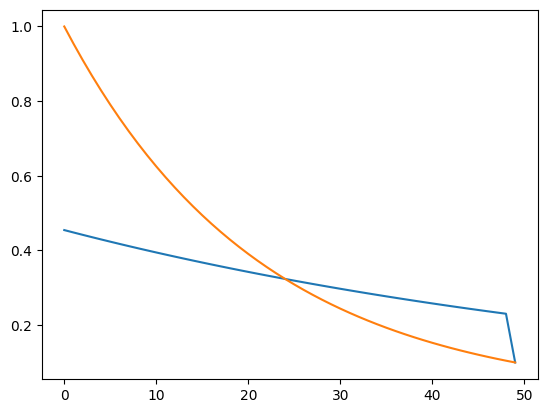

In [102]:
plt.plot(origin)
plt.plot(target)
plt.show()

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
np.random.seed(15)

n = 1000
k = 50
r = 10
A = np.random.randn(n,n)
Q, _ = np.linalg.qr(A)
# Q = np.eye(n)
end = 50
S = np.concatenate([
    10**np.linspace(0, -5, end),
    10**np.linspace(-5, -12, n-end)])
S = 10**(np.linspace(0, -24, n))



Sk_list = [10**np.linspace(0, -x, end) for x in [1,3,5,8]]
# Sk_list.extend([10**np.linspace(3, -x, end) for x in [1,3,5,8]])
Sk_list.append(10**(-5/2)*np.ones(end))
Sk_rest_list = [10**np.linspace(-8, -9, n-end), 10**np.linspace(-8, -12, n-end), 10**np.linspace(-8, -16, n-end), np.zeros(n-end), 1e-12*np.ones(n-end), 1e-16*np.ones(n-end)]
# Sk_rest_list.append



# Same sum
target = 10**np.linspace(0, -1, end)
origin = 2**np.linspace(0, -1, end)
# gap = target[-1] - origin[-1]
origin[-1] = target[-1]
mean_diff = target.mean()-origin.mean()
origin[:-1] += mean_diff + mean_diff/(len(target)-1) 
origin = np.sort(origin)[::-1]
Sk_list.append(origin)

# Same product
target = 10**np.linspace(0, -1, end)
origin = 2**np.linspace(0, -1, end)
# gap = target[-1] - origin[-1]
origin[-1] = target[-1]
mean_diff = np.power((target/origin).prod(), 1/len(target))
origin[:-1] *= mean_diff * np.power(mean_diff, 1/(len(target)-1)) 
origin = np.sort(origin)[::-1]
Sk_list.append(origin)

# Same start/end point
origin = 10**np.linspace(0,-1/3, end//2)
origin = np.concatenate([
    origin, 10**np.linspace(-1/2, -1, end-end//2)
])
Sk_list.append(origin)

errors = []
traces = []
Sk_prop = []
for Sk, Sk_rest in itertools.product(Sk_list, Sk_rest_list):
#     print(Sk.shape, Sk_rest.shape)
    S = np.concatenate([Sk, Sk_rest])
#     continue
    A = Q @ np.diag(S) @ Q.T
    A11 = A[:k, :k]
    S11, V11 = np.linalg.eig(A11)

    a12_factor = 1.0
    A12 = a12_factor * A[:k, k:]
    G = np.zeros((n, k))
    G[:k, :] = V11 @ np.diag(np.sqrt(S11)) @ V11.T 
    G[k:, :] =  A12.T @ V11 @ np.diag((1/np.sqrt(S11))) @ V11.T 
    U_G, S_G, V_G = np.linalg.svd(G, full_matrices=False)
    S_approx = S_G**2
    
    # Threshold S11 before taking its inverse
    threshold_factor = 1.0
    S11_inv = np.zeros_like(S11)
    mask = S11 > threshold_factor * k * np.finfo(float).eps * np.max(np.abs(S11))
    S11_inv[mask] = 1 / S11[mask]

    # Create a diagonal matrix from the thresholded inverse
    S11_inv_diag = np.diag(S11_inv)

    
    err =  np.linalg.norm(A[k:, k:] - A[:k, k:].T @ V11[:,:] @ np.diag(S11_inv) @ V11[:,:].T @ A[:k, k:])
    errors.append(err)
    
    traces.append(S.sum())
#     Sk_prop.append(np.log10(Sk_rest).sum() / (np.log10(Sk_rest).sum() + np.log10(Sk).sum()) )
    Sk_prop.append((Sk_rest).sum() / ((Sk_rest).sum() + (Sk).sum()) )
#     print(np.linalg.norm(A[r:, r:] - A[:k, r:].T @ V11[:,:] @ np.diag(S11_inv) @ V11[:,:].T @ A[:k, r:]),\
#     np.linalg.norm(A[:r, :r] - U_G[:r, :] @ np.diag(S_approx) @ U_G[:r, :].T),\
#     np.linalg.norm(A[:r, r:] - U_G[:r, :] @ np.diag(S_approx) @ U_G[r:, :].T),\
#     np.linalg.norm(Q[r:, :r] @ np.diag(S[:r]) @ Q[r:, :r].T - U_G[r:, :] @ np.diag(S[:r]) @ U_G[r:,:].T),\
#     np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ Q[k:,:].T),\
#     np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S)) @ Q[k:,:].T),\
#     np.linalg.norm((np.diag(S)) @ Q[k:,:].T),\
#     np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S))),\
#     np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S)) ),\
#     np.linalg.norm((np.diag(S))),
#     np.linalg.norm(A[k:, k:] - A[:k, k:].T @ V11[:,:] @ np.diag(S11_inv) @ V11[:,:].T @ A[:k, k:])
#          )
#     break

In [104]:
Sk_rest_list[0].sum() / (Sk_list[3].sum() + Sk_rest_list[0].sum())

1.1640389672119463e-06

In [105]:
# [errors[len(Sk_rest_list)*i:len(Sk_rest_list)*(i+1)] for i in range(len(Sk_list))]

In [106]:
# Reshape the data into the structure for the table
n_Sk = len(Sk_list)
n_Sk_rest = len(Sk_rest_list)
# reshaped_errors = [np.array(errors[n_Sk_rest*i:n_Sk_rest*(i+1)]) / np.array(traces[n_Sk_rest*i:n_Sk_rest*(i+1)]) for i in range(n_Sk)]
reshaped_errors = [np.array(errors[n_Sk_rest*i:n_Sk_rest*(i+1)]) for i in range(n_Sk)]
# reshaped_prop = [np.array(Sk_prop[n_Sk_rest*i:n_Sk_rest*(i+1)]) for i in range(n_Sk)]
# reshaped_traces = [traces[n_Sk_rest*i:n_Sk_rest*(i+1)] for i in range(n_Sk)]
# reshaped_errors = reshaped_prop

# Build the column specification based on n_Sk_rest
col_spec = "c r " + "r" * n_Sk_rest

caption = "Approximation Errors of the Nyström Method for Different Spectrum Configurations"

# Start building the LaTeX table
table = f"""\\begin{{table}}[!htb]
\\centering
\\footnotesize
\\caption{{{caption}}}
\\label{{tab:nystrom_errors}}
\\begin{{tabular}}{{ {col_spec} }} 
% \\hline
\\toprule
% & & \\multicolumn{{{n_Sk_rest}}}{{c}}{{}} \\\\ 
% \\cmidrule(l){{3-{2+n_Sk_rest}}} 
&  """

# Add column headers
for j in range(1, n_Sk_rest + 1):
    table += f"& $S_{{r{j}}}$"
table += "\\\\ \n% \\hline\n\\midrule\n"

# Add rows with the error values in scientific notation
for i in range(n_Sk):
    row_values = " & ".join([f"{val:.7e}" for val in reshaped_errors[i]])
    if i == 0:
        table += f"k={k}& $S_{{k{i+1}}}$& {row_values} \\\\\n"
    else:
        table += f"& $S_{{k{i+1}}}$& {row_values} \\\\\n"

# Finish the table
table += """% \\hline
\\bottomrule
\\end{tabular}
\\end{table}"""
print(table)

\begin{table}[!htb]
\centering
\footnotesize
\caption{Approximation Errors of the Nyström Method for Different Spectrum Configurations}
\label{tab:nystrom_errors}
\begin{tabular}{ c r rrrrrr } 
% \hline
\toprule
% & & \multicolumn{6}{c}{} \\ 
% \cmidrule(l){3-8} 
&  & $S_{r1}$& $S_{r2}$& $S_{r3}$& $S_{r4}$& $S_{r5}$& $S_{r6}$\\ 
% \hline
\midrule
k=50& $S_{k1}$& 2.3229938e-04 & 5.7583918e-05 & 2.7296106e-05 & 2.1016026e-13 & 6.1224095e-08 & 4.1035303e-12 \\
& $S_{k2}$& 2.2926112e-04 & 5.7392243e-05 & 2.7250099e-05 & 1.0531235e-13 & 6.1224072e-08 & 4.7317391e-12 \\
& $S_{k3}$& 1.4273296e-04 & 4.9292645e-05 & 2.5114158e-05 & 8.9018528e-14 & 6.1213432e-08 & 5.1877217e-12 \\
& $S_{k4}$& 6.8311331e-06 & 3.3960273e-06 & 2.3528282e-06 & 1.5213971e-13 & 5.5755444e-08 & 5.4749891e-12 \\
& $S_{k5}$& 2.1816582e-04 & 5.6702320e-05 & 2.7096014e-05 & 2.4271854e-15 & 6.1223192e-08 & 6.1073837e-12 \\
& $S_{k6}$& 2.3231671e-04 & 5.7585033e-05 & 2.7296386e-05 & 2.8777589e-13 & 6.1224557e-08 & 4.4342101e

+ gap
+ mass of tail

In [107]:
# Create a separate description table
description_table = """\\begin{table}[!htb]
\\centering
\\footnotesize
\\caption{Description of Spectrum Configurations}
\\label{tab:spectrum_descriptions}
\\begin{tabular}{l p{12cm}} 
\\toprule
\\textbf{Notation} & \\textbf{Description} \\\\ 
\\midrule
"""

# Top spectrum descriptions
description_table += "$S_{k1}$ & Spectrum decaying from 1 to $10^{-1}$ (moderate decay) \\\\\n"
description_table += "$S_{k2}$ & Spectrum decaying from 1 to $10^{-3}$ (faster decay) \\\\\n"
description_table += "$S_{k3}$ & Spectrum decaying from 1 to $10^{-5}$ (steep decay) \\\\\n"
description_table += "$S_{k4}$ & Spectrum decaying from 1 to $10^{-8}$ (very steep decay) \\\\\n"
description_table += "$S_{k5}$ & Spectrum with same sum and same endpoint as $S_{k1}$ \\\\\n"
description_table += "$S_{k6}$ & Spectrum with same product and same endpoint as $S_{k1}$ \\\\\n"
description_table += "$S_{k7}$ & Spectrum with same start/end as $S_{k1}$ \\\\\n"
description_table += "\\midrule\n"

# Bottom spectrum descriptions
description_table += "$S_{r1}$ & Tail spectrum decaying from $10^{-8}$ to $10^{-9}$ (slight further decay) \\\\\n"
description_table += "$S_{r2}$ & Tail spectrum decaying from $10^{-8}$ to $10^{-12}$ (moderate further decay) \\\\\n"
description_table += "$S_{r3}$ & Tail spectrum decaying from $10^{-8}$ to $10^{-16}$ (steep further decay) \\\\\n"
description_table += "$S_{r4}$ & Tail spectrum with all zeros \\\\\n"
description_table += "$S_{r5}$ & Tail spectrum with constant values $10^{-12}$ \\\\\n"
description_table += "$S_{r6}$ & Tail spectrum with constant values $10^{-16}$ \\\\\n"

# Finish the description table
description_table += """\\bottomrule
\\end{tabular}
\\end{table}"""
print(description_table)

\begin{table}[!htb]
\centering
\footnotesize
\caption{Description of Spectrum Configurations}
\label{tab:spectrum_descriptions}
\begin{tabular}{l p{12cm}} 
\toprule
\textbf{Notation} & \textbf{Description} \\ 
\midrule
$S_{k1}$ & Spectrum decaying from 1 to $10^{-1}$ (moderate decay) \\
$S_{k2}$ & Spectrum decaying from 1 to $10^{-3}$ (faster decay) \\
$S_{k3}$ & Spectrum decaying from 1 to $10^{-5}$ (steep decay) \\
$S_{k4}$ & Spectrum decaying from 1 to $10^{-8}$ (very steep decay) \\
$S_{k5}$ & Spectrum with same sum and same endpoint as $S_{k1}$ \\
$S_{k6}$ & Spectrum with same product and same endpoint as $S_{k1}$ \\
$S_{k7}$ & Spectrum with same start/end as $S_{k1}$ \\
\midrule
$S_{r1}$ & Tail spectrum decaying from $10^{-8}$ to $10^{-9}$ (slight further decay) \\
$S_{r2}$ & Tail spectrum decaying from $10^{-8}$ to $10^{-12}$ (moderate further decay) \\
$S_{r3}$ & Tail spectrum decaying from $10^{-8}$ to $10^{-16}$ (steep further decay) \\
$S_{r4}$ & Tail spectrum with all zeros

In [108]:
np.sqrt(2)/2

0.7071067811865476

/tmp/ipykernel_4416/1622384204.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


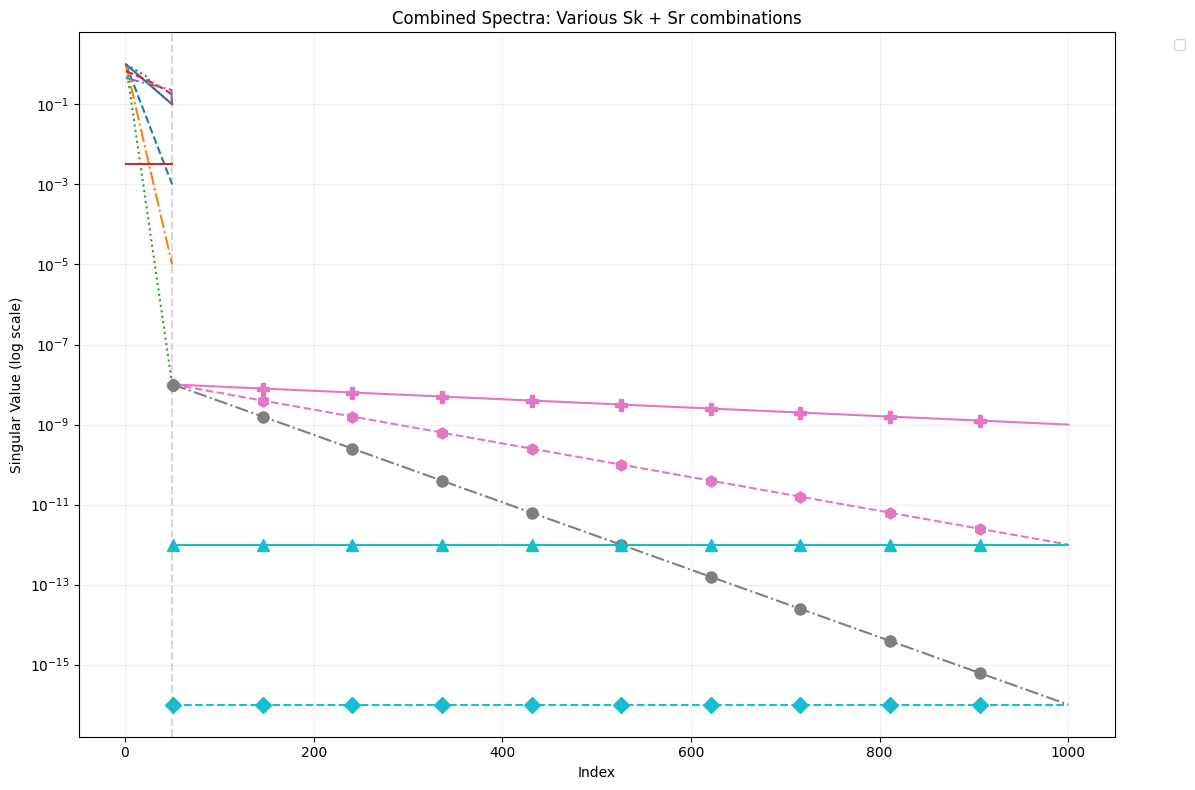

In [109]:
import numpy as np
import matplotlib.pyplot as plt

# n = 1000
# end = 50
z = 1000

# Create the lists
# Sk_list = [10**np.linspace(0, -x, end) for x in [1,3,5,8]]
# Sk_rest_list = [
#     10**np.linspace(-8, -9, n-end),
#     10**np.linspace(-8, -12, n-end),
#     10**np.linspace(-8, -16, n-end),
#     np.zeros(n-end),
#     1e-12*np.ones(n-end),
#     1e-16*np.ones(n-end)
# ]

# Create plot
plt.figure(figsize=(12, 8))

# Define distinct markers that are easily distinguishable
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'P', 'h']
marker_size = 8  # Larger marker size for better visibility

# Plot all combinations
line_styles = ['-', '--', '-.', ':']
colors = plt.cm.tab10(np.linspace(0, 1, len(Sk_list) + len(Sk_rest_list)))
color_idx = 0


for i, sk in enumerate(Sk_list):
    # Concatenate the spectra
    full_spectrum = np.concatenate([sk])

    # Create indices for x-axis (1 to n)
    indices = np.arange(1, end+1)

    # Plot with label indicating the combination
#     label = f"{Sk_names[i]}"
    plt.semilogy(indices, full_spectrum, 
#                  label=label, 
                 linestyle=line_styles[i % len(line_styles)],
                 color=colors[color_idx],
#                  marker=markers[i % len(markers)],
                 markevery=max(1, len(indices)//5),  # Show markers at intervals
                 markersize=marker_size)
    color_idx += 1

for j, sk_rest in enumerate(Sk_rest_list):
    full_spectrum = np.concatenate([sk_rest])[:z]
    
    # Create indices for x-axis (1 to n)
    indices = np.arange(end+1, n+1)[:z]

    # Plot with label indicating the combination
#     label = f"{Sk_rest_names[j]}"
    plt.semilogy(indices, full_spectrum, 
#                  label=label, 
                 linestyle=line_styles[j % len(line_styles)],
                 color=colors[color_idx],
                 marker=markers[(j+len(Sk_list)) % len(markers)],
                 markevery=max(1, len(indices)//10),  # Show markers at intervals
                 markersize=marker_size)
    color_idx += 1
    
# Add a vertical line to separate Sk and Sk_rest
plt.axvline(x=end, color='gray', linestyle='--', alpha=0.3)

# Add grid, labels, and legend
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Combined Spectra: Various Sk + Sr combinations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [110]:
x = -5
np.exp(np.log((10**np.linspace(0, x, end))).mean()), 10**(x/2)

(0.0031622776601683764, 0.0031622776601683794)

In [111]:
1e-3*5

0.005

In [112]:
list(itertools.product([1,2,3], [1,2]))

[(1, 1), (1, 2), (2, 1), (2, 2), (3, 1), (3, 2)]

In [113]:
len(errors)

48

In [114]:
np.concatenate(Sk_rest_list).reshape(len(Sk_rest_list), -1).sum(axis=1)

array([3.71481099e-06, 1.03526921e-06, 5.20197999e-07, 0.00000000e+00,
       9.50000000e-10, 9.50000000e-14])

In [115]:
np.concatenate(Sk_list).reshape(len(Sk_list), -1).sum(axis=1)

array([19.70591089,  7.59861531,  4.77560998,  3.19130783,  0.15811388,
       19.70591089, 16.28288999, 22.2053234 ])

In [622]:
import numpy as np
np.random.seed(12)

n = 1000
k = 50
r = 10
A = np.random.randn(n,n)

import numpy as np
from scipy.stats import entropy

def create_orthonormal_matrix(n, high_conc=3, med_conc=3):
    # Total special columns
    special_cols = high_conc + med_conc
    
    # Much more distinct concentration levels
    high_density = max(1, n // 50)     # ~2% non-zero elements
    med_density = max(1, n // 4)       # ~12.5% non-zero elements
    
    # Initialize matrix
    concentrated = np.zeros((n, n))
    
    # Generate high concentration columns (very sparse)
    for i in range(high_conc):
        v = np.zeros(n)
        positions = np.random.choice(n, high_density, replace=False)
        v[positions] = np.random.normal(0, 1, high_density)
        concentrated[:, i] = v
    
    # Generate medium concentration columns
    for i in range(high_conc, high_conc + med_conc):
        v = np.zeros(n)
        positions = np.random.choice(n, med_density, replace=False)
        v[positions] = np.random.normal(0, 1, med_density)
        concentrated[:, i] = v
    
    # The rest with low concentration
    remaining = np.random.normal(0, 1, (n, n-special_cols))
    concentrated[:, special_cols:] = remaining
    Q, _ = np.linalg.qr(concentrated[:, :], mode='complete')    
    return Q

# Example usage
np.random.seed(10)
Q = create_orthonormal_matrix(n, high_conc=3, med_conc=3)

# Calculate entropy for each column
entropies = []
for i in range(n):
    col = Q[:, i]
    prob_dist = np.abs(col)
    col_entropy = entropy(prob_dist)  # higher entropy means more spread out, lower means more concentrated)
    entropies.append(col_entropy)

# Reorder Q by entropy
new_order = np.argsort(entropies)
Q_reordered = Q[:, new_order]

# Create sorted list of entropies
sorted_entropies = [entropies[i] for i in new_order]
# Q, _ = np.linalg.qr(A)
# Q = np.eye(n)
end = 50
# S = np.concatenate([
#     10**np.linspace(0, -5, end),
#     10**np.linspace(-5, -12, n-end)])
# S = 10**(np.linspace(0, -24, n))
S = np.concatenate([
#     Sk_list[0], 
    10**np.linspace(1, -5, end),
#     Sk_rest_list[0]
    10**np.linspace(-8, -12, n-end),
#     np.zeros(n-end)
])
A = Q @ np.diag(S) @ Q.T
A11 = A[:k, :k]
S11, V11 = np.linalg.eig(A11)
# S11, S, V11, Q



In [623]:
np.abs(Q[l_highest,0])

array([0.0124208 , 0.04701519, 0.05956232, 0.08789868, 0.07361809,
       0.08894828, 0.09051384, 0.12268153, 0.39335521, 0.21989481,
       0.17136953, 0.19177398, 0.26551061, 0.10037798, 0.5501682 ,
       0.24427454, 0.15655173, 0.33189967, 0.29465201, 0.12707214])

In [624]:
np.random.seed(100)
w = 100
l = 20
l_highest = np.argpartition(np.abs(Q[:,0]), -l)[-l:]
# l_highest = np.argpartition(np.abs(Q[:,0]), l)[:l]
the_rest = np.setdiff1d(np.random.choice(n, n), l_highest)
current_window = np.concatenate([
    l_highest[:1],
    the_rest,
])
current_window = current_window[:w]

In [625]:
np.linalg.norm(Q[current_window, :10], axis=0)**2

array([1.54276287e-04, 8.30429641e-02, 5.19713841e-05, 9.84631444e-02,
       9.14640540e-02, 1.24197263e-01, 9.01236737e-02, 9.41330630e-02,
       1.03198724e-01, 1.06615167e-01])

In [626]:
np.random.randint


Up, Sp, Vtp = np.linalg.svd(A[current_window, :], full_matrices=False)

In [627]:
np.random.seed(10)

# x = np.random.randn(n)
# x = x / np.linalg.norm(x)

x = Vtp[0, :]

temp = Q[current_window, :] @ np.diag(S) @ Q.T @ x
np.linalg.norm(A[current_window, :] @ x)**2, temp.T @ temp, 

(4.741662541159992, 4.741662541159995)

In [628]:
sum_temp = 0
sums = np.zeros((Q.shape[1], Q.shape[1]))
for i in range(Q.shape[1]):
    for j in range(Q.shape[1]):
        sums[i,j] = ((S[i] * Q[:, i].T @ x) * (S[j] * Q[:, j].T @ x) * (Q[current_window, i].T @ Q[current_window, j]))
        sum_temp += sums
sum_temp

KeyboardInterrupt: 

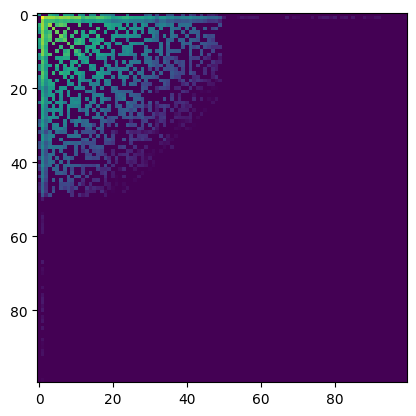

In [617]:
plt.imshow(np.log10(np.clip(sums, 1e-20, None))[:100, :100])
plt.show()

In [621]:
sums[1,1], sums[0,0], sums[1,2]

(4.704904166245084, 5.175296316488067e-10, 0.00167538361436468)

In [593]:
temp.shape

(1000,)

In [589]:
np.linalg.norm(A[current_window, :] @ Q[0,:])

0.0959077349460546

In [613]:
i = 0
Vtp[i, :] @ A @ Vtp[i, :], S[:5], Sp[0], np.linalg.norm(Q[current_window, i]) * S[i], np.linalg.norm(Q[current_window, 1]) * S[1]

(7.524351436556175,
 array([10.        ,  7.54312006,  5.68986603,  4.29193426,  3.23745754]),
 2.1775358874562754,
 0.12420800585844896,
 2.1737141953247887)

In [ ]:
import numpy as np
from scipy.linalg import svd

# Given matrix A (example matrix, replace with your actual data)

# Parameters
window_size = k # Number of rows per window
is_first_window = True
SV_T = None

# Calculate number of windows
n_rows = A.shape[0]
n_windows = (n_rows + window_size - 1) // window_size

# Process each window incrementally
for i in range(n_windows):
    # Extract current window of rows
    start_idx = i * window_size
    end_idx = min(start_idx + window_size, n_rows)
    current_window = A[start_idx:end_idx, :]
    
    print(f"\nProcessing window {i+1}/{n_windows}:")
    print(f"Rows {start_idx} to {end_idx-1}")
#     print(current_window)
    
    if is_first_window:
        # First window: compute standard SVD
        U, S_, V_T = svd(current_window, full_matrices=False)
        
        # Truncate to k components
        U = U[:, :r]
        S_ = S_[:r]
        V_T = V_T[:r, :]
        
        # Store S * V^T for next update
        SV_T = np.diag(S_) @ V_T
        is_first_window = False
        
        print(f"First window SVD complete")
        print(f"S: {S_}")
    else:
        # Not the first window: append new rows to current SV_T
        combined = np.vstack([SV_T, current_window])
        
        # Compute SVD of the combined matrix
        U, S_, V_T = svd(combined, full_matrices=False)
        
        # Truncate to k components
        U = U[:, :r]
        S_ = S_[:r]
        V_T = V_T[:r, :]
        
        # Update the stored SV_T
        SV_T = np.diag(S_) @ V_T
        print(f"S: {S_}")
    S_quotient = np.zeros(S_.shape)
    for i in range(r):
#         v = V_T.T[:, :r]
        S_quotient[i] = np.dot(V_T[i, window].T, A[window, :] @ V_T[i, :].T) / np.dot(V_T[i, window], V_T[i, window])
    print(S_quotient)
    print("S*norm:\n", S[:r] * np.linalg.norm(Q[:end_idx, :r], axis=0))
    print("norm:\n", np.sum(Q[:end_idx, :r] * np.abs(Q[:end_idx, :r]), axis=0))
    print("diff w. S*norm:\n", (S_ - S[:r] * np.linalg.norm(Q[:end_idx, :r], axis=0)) / (S[:r] * np.linalg.norm(Q[:end_idx, :r], axis=0)))
    
    # Try to find svd of all windows until now
    _, S_all, Vt_all = svd(A[:end_idx], full_matrices=False)
    print(S_all[:r])
    print("Diff with all:", (S_ - S_all[:r]) / S_all[:r])
    
#     print(f"SV_T after window {i+1}:")
#     print(SV_T)

print("\nFinal low-rank representation (SV_T):")
# print(SV_T)
print(f"Shape: {SV_T.shape}")

# Verify the approximation by computing a full SVD of the original matrix
U_full, S_full, V_T_full = svd(A, full_matrices=False)
# Truncate to k components
U_full = U_full[:, :r]
S_full = S_full[:r]
V_T_full = V_T_full[:r, :]
full_approx = U_full @ np.diag(S_full) @ V_T_full

print("\nDirect SVD low-rank approximation:")
print(np.diag(S_full) @ V_T_full)
print(f"Shape: {(np.diag(S_full) @ V_T_full).shape}")

# Calculate the difference between incremental and direct methods
diff = np.linalg.norm(SV_T - np.diag(S_full) @ V_T_full)
print(f"\nFrobenius norm of difference between methods: {diff}")


Processing window 1/20:
Rows 0 to 49
First window SVD complete
S: [2.62686859 1.67823191 1.26645867 1.04794761 0.81591236 0.56541231
 0.40194356 0.25355986 0.22002328 0.16432893]
[9.65724372 7.22091504 5.82619241 4.11350669 3.61718208 2.22120724
 1.7990882  1.16391111 1.32496658 0.76889693]
S*norm:
 [2.60469764 1.62633583 1.35516808 1.03999855 0.82680113 0.58273163
 0.41928313 0.22218932 0.26830556 0.16835963]
norm:
 [-0.01842103 -0.01298566 -0.00525324 -0.01163991 -0.02081311  0.00400052
 -0.01926567 -0.00047549  0.02604792  0.00071252]
diff w. S*norm:
 [ 0.00851191  0.03190982 -0.06546008  0.00764334 -0.01316976 -0.02972091
 -0.04135527  0.14118832 -0.17995261 -0.02394104]
[2.62686859 1.67823191 1.26645867 1.04794761 0.81591236 0.56541231
 0.40194356 0.25355986 0.22002328 0.16432893]
Diff with all: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Processing window 2/20:
Rows 50 to 99
S: [3.42915359 2.40310903 1.83480039 1.46654995 1.12674554 0.79499974
 0.55538388 0.36233585 0.33319161 0.24985931]


In [281]:
S[:r], S_[:r], S_quotient

(array([10.        ,  7.54312006,  5.68986603,  4.29193426,  3.23745754,
         2.44205309,  1.84206997,  1.38949549,  1.04811313,  0.79060432]),
 array([9.99999972, 7.54311939, 5.68986563, 4.2919333 , 3.23744427,
        2.4420356 , 1.84199566, 1.38925203, 1.04792682, 0.78873322]),
 array([10.0000405 ,  7.5432151 ,  5.68995485,  4.29191323,  3.23725255,
         2.44175218,  1.84118871,  1.38900102,  1.04734047,  0.79809604]))

In [282]:
(S_quotient - S[:r]) / S[:r], (S_[:r] - S[:r]) / S[:r], 

(array([ 4.04951216e-06,  1.25986209e-05,  1.56102840e-05, -4.89960416e-06,
        -6.33195942e-05, -1.23222848e-04, -4.78404972e-04, -3.55869169e-04,
        -7.37198597e-04,  9.47594209e-03]),
 array([-2.80241075e-08, -8.96539499e-08, -6.95626811e-08, -2.23672170e-07,
        -4.09996316e-06, -7.16387582e-06, -4.03374947e-05, -1.75217508e-04,
        -1.77766024e-04, -2.36666940e-03]))

In [276]:
# A[:k, :k]

In [277]:
# Q[:k, :k] @ np.diag(S[:k]) @ Q[:k, :k].T

In [278]:
a12_factor = 1.0
A12 = a12_factor * A[:k, k:]
threshold_factor = 1.0
S11_inv = np.zeros_like(S11)
mask = S11 > threshold_factor * k * np.finfo(float).eps * np.max(np.abs(S11))
S11_inv[mask] = 1 / S11[mask]
G = np.zeros((n, k))
G[:k, :] = V11 @ np.diag(np.sqrt(S11)) @ V11.T 
G[k:, :] =  A12.T @ V11 @ np.diag((S11_inv)) @ V11.T 
U_G, S_G, V_G = np.linalg.svd(G, full_matrices=False)
S_approx = S_G**2

In [279]:
k_norm = np.linalg.norm(Q[:k, :] @ np.diag(S) @ Q.T @ Q[:,0])
r_norm = S[0] * np.linalg.norm(Q[k:, 0])
norm = k_norm**2 + r_norm**2

np.linalg.norm(np.diag(S) @ Q.T @ Q[:,0]), k_norm, r_norm, np.sqrt(norm)

(10.000000000000002, 2.604697637497336, 9.654820051001252, 10.000000000000002)

In [235]:
Q

array([[-0.01486752,  0.02203771,  0.00841019, ..., -0.02009336,
        -0.0187177 ,  0.04434808],
       [-0.05938226, -0.0560429 , -0.00200415, ...,  0.00434055,
        -0.05534051,  0.02512043],
       [-0.00546528, -0.00767459, -0.05884762, ...,  0.0117435 ,
        -0.0631828 ,  0.030943  ],
       ...,
       [-0.0502357 ,  0.00939736,  0.02249574, ...,  0.01582365,
        -0.01488289,  0.05726562],
       [-0.01286008, -0.07738549,  0.02634807, ...,  0.02562154,
         0.01743876, -0.0093831 ],
       [ 0.00520873, -0.04908904, -0.04547475, ..., -0.0413375 ,
         0.00029159, -0.02311196]])

In [283]:
window = np.arange(k,k+10)
S_new = np.sqrt(S[:r]**2 - S[:r]**2 * np.linalg.norm(Q[window, :r], axis=0)**2)
# u, s, v = np.linalg.svd(np.concatenate([np.diag(S_new) @ Q[:,:r].T, np.diag(S * np.linalg.norm(Q[window, :], axis=0)) @ Q.T]))
u, s, v = np.linalg.svd(np.concatenate([np.diag(S_new) @ Q[:,:r].T, A[window, :]]))
s[:10], (s[:r] - S[:r]) / S[:r]

(array([10.00011902,  7.54319782,  5.68973   ,  4.29180961,  3.2374769 ,
         2.44204803,  1.84186942,  1.38947724,  1.0480814 ,  0.79057433]),
 array([ 1.19017373e-05,  1.03085126e-05, -2.39077820e-05, -2.90437307e-05,
         5.98031018e-06, -2.07231615e-06, -1.08870509e-04, -1.31406824e-05,
        -3.02729158e-05, -3.79372365e-05]))

In [288]:
u, s, v = np.linalg.svd(np.concatenate([np.delete(Q[:,:r], window, axis=0) @ np.diag(S[:r]) @ Q[:,:r].T, A[window, :]]))
s[:10], (s[:r] - S[:r]) / S[:r]

(array([10.00000025,  7.54312219,  5.68986722,  4.29193586,  3.23745788,
         2.4420572 ,  1.8420718 ,  1.38949683,  1.04811565,  0.79062421]),
 array([2.51140891e-08, 2.82041358e-07, 2.09769717e-07, 3.72685655e-07,
        1.05631220e-07, 1.67970192e-06, 9.92538024e-07, 9.58096898e-07,
        2.39978065e-06, 2.51601200e-05]))

In [237]:
s[:10] - S[:10]

array([ 2.14570578e-04,  2.26770016e-04, -2.08384177e-04, -1.68655992e-04,
        7.83183499e-05,  9.76882811e-05, -4.60844161e-04, -1.30260086e-05,
       -7.71703827e-05, -7.19171356e-05])

In [242]:
np.linalg.norm(np.diag(S_new) @ Q[:,:r].T, ord=2), np.linalg.norm(np.delete(Q[:, :r], window, axis=0) @ np.diag(S[:r]) @ Q[:,:r].T, ord=2)

(9.973227765587671, 9.97343777342692)

In [244]:
i = 0
v = Q[:, :r].T
np.dot(v[i, window].T, A[window, :] @ v[i].T) / np.dot(v[i, window].T, v[i, window].T)

10.000000000000002

In [214]:
u, s, v = np.linalg.svd(np.concatenate([np.diag(np.linalg.norm(np.delete(A, window, axis=0) @ Q[:,:r], axis=0)) @ Q[:,:r].T, A[window, :]]))
s[:10]

array([10.00009406,  7.1969003 ,  5.17936139,  3.72748689,  2.68270398,
        1.93067962,  1.38935764,  0.99998459,  0.71966476,  0.51792771])

In [247]:
u, s, v = np.linalg.svd(np.concatenate([np.delete(Q[:,:100], window, axis=0) @ np.diag(S[:100]) @ Q[:,:100].T, A[window, :]]))
s[:10]

array([10.        ,  8.28642773,  6.86648845,  5.68986603,  4.71486636,
        3.90693994,  3.23745754,  2.6826958 ,  2.22299648,  1.84206997])

In [253]:
S[:r]

array([10.        ,  8.28642773,  6.86648845,  5.68986603,  4.71486636,
        3.90693994,  3.23745754,  2.6826958 ,  2.22299648,  1.84206997])

In [153]:
np.random.seed(0)
x = np.random.rand(n) 
x = x / np.linalg.norm(x)
np.linalg.norm(np.concatenate([np.diag(S_new) @ Q[:,:r].T, A[window, :]]) @ x)**2, np.linalg.norm(A @ x)**2

(0.4899946333763111, 0.4963867722942682)

In [168]:
np.linalg.norm(np.delete(Q[:,:r], window, axis=0) @ np.diag(S[:r]) @ Q[:,:r].T @ x)**2, np.linalg.norm(np.diag(S_new) @ Q[:,:r].T @ x)**2

(0.4834979875888785, 0.48493507098586275)

In [161]:
np.linalg.norm(np.delete(A, window, axis=0) @ x)**2, np.linalg.norm(A[window,:] @ x)**2

(0.4913272099038198, 0.005059562390448504)

In [162]:
np.linalg.norm(np.concatenate([np.delete(Q, window, axis=0)[:,:r] @ np.diag(S[:r]) @ Q[:,:r].T, A[window, :]]) @ x)**2

0.488557549979327

In [145]:
np.linalg.norm(np.diag(np.sqrt(S[:]**2 - S[:]**2 * np.linalg.norm(Q[window, :], axis=0)**2)) @ Q[:,:].T @ x)**2

0.46178173605261363

In [122]:
np.concatenate([np.diag(S_new) @ Q[:,:r].T, A[window, :]]) @ Q[:,1]

array([-3.88578059e-16,  8.22297891e+00, -1.38777878e-17,  1.59594560e-16,
        1.07552856e-16, -2.08166817e-17,  0.00000000e+00, -5.55111512e-17,
       -1.38777878e-17,  1.04083409e-17,  1.43644261e-01,  7.74808118e-01,
       -7.09224749e-02,  2.90514415e-01, -3.14601759e-01,  9.71831585e-02,
       -9.90584651e-02,  4.01041621e-01, -2.06035794e-01, -1.24883533e-01])

In [128]:
np.sum((np.diag(S_new) @ Q[:,:r].T @ Q[:,1])**2), np.sum((A[window, :] @ Q[:,1])**2)

(67.6173821444647, 1.047502355965339)

In [125]:
np.diag(S_new) @ Q[:,:r].T @ Q[:,1], A[window, :] @ Q[:,1]

(array([-3.88578059e-16,  8.22297891e+00, -1.38777878e-17,  1.59594560e-16,
         1.07552856e-16, -2.08166817e-17,  0.00000000e+00, -5.55111512e-17,
        -4.51028104e-17, -2.42861287e-17]),
 array([ 0.14364426,  0.77480812, -0.07092247,  0.29051442, -0.31460176,
         0.09718316, -0.09905847,  0.40104162, -0.20603579, -0.12488353]))

In [133]:
np.linalg.norm(np.diag(S_new) @ Q[:,:r].T @ Q[:,1]), np.linalg.norm(A[window, :] @ Q[:,1])

(8.222978909401672, 1.0234756254866744)

In [115]:
np.linalg.norm(np.delete(Q, window, axis=0) @ np.diag(S) @ Q[:,:].T @ Q[:,1]),\
np.linalg.norm(Q[window,:] @ np.diag(S) @ Q[:,:].T @ Q[:,1])

(8.222978909401672, 1.0234756254866741)

In [119]:
np.sqrt(S[:r]**2 * np.linalg.norm(Q[window, :r], axis=0)**2)

array([0.73125094, 1.02347563, 0.52673801, 0.65234991, 0.31837856,
       0.58121427, 0.33799297, 0.29916244, 0.20334352, 0.20133924])

In [109]:
np.sqrt(S_new[1]**2 + (np.linalg.norm(Q[window, 1], axis=0)**2))

8.223906457947924

In [110]:
S[1]

8.286427728546844

In [88]:
np.delete(Q, window, axis=0).shape

(990, 1000)

In [75]:
np.concatenate([np.diag(S_new) @ Q[:,:r].T, A[window, :]]).shape

(20, 1000)

In [101]:
S_new[:10], S[:10]

(array([9.97322777, 8.22297891, 6.84625523, 5.65234597, 4.70410458,
        3.86346601, 3.21976584, 2.66596297, 2.21367675, 1.83103366]),
 array([10.        ,  8.28642773,  6.86648845,  5.68986603,  4.71486636,
         3.90693994,  3.23745754,  2.6826958 ,  2.22299648,  1.84206997]))

array([1.00000000e+01, 8.28642773e+00, 6.86648845e+00, 5.68986603e+00,
       4.71486636e+00, 3.90693994e+00, 3.23745754e+00, 2.68269580e+00,
       2.22299648e+00, 1.84206997e+00, 1.52641797e+00, 1.26485522e+00,
       1.04811313e+00, 8.68511374e-01, 7.19685673e-01, 5.96362332e-01,
       4.94171336e-01, 4.09491506e-01, 3.39322177e-01, 2.81176870e-01,
       2.32995181e-01, 1.93069773e-01, 1.59985872e-01, 1.32571137e-01,
       1.09854114e-01, 9.10298178e-02, 7.54312006e-02, 6.25055193e-02,
       5.17947468e-02, 4.29193426e-02, 3.55648031e-02, 2.94705170e-02,
       2.44205309e-02, 2.02358965e-02, 1.67683294e-02, 1.38949549e-02,
       1.15139540e-02, 9.54095476e-03, 7.90604321e-03, 6.55128557e-03,
       5.42867544e-03, 4.49843267e-03, 3.72759372e-03, 3.08884360e-03,
       2.55954792e-03, 2.12095089e-03, 1.75751062e-03, 1.45634848e-03,
       1.20679264e-03, 1.00000000e-03, 1.00000000e-05, 9.97576613e-06,
       9.95159099e-06, 9.92747444e-06, 9.90341633e-06, 9.87941653e-06,
      

In [32]:
ei = np.zeros(n)
ei[0] = 1
S[0] * np.linalg.norm(Q[:k, 0]), S[0] * np.linalg.norm(Q[:, :] @ ei)

(2.6046976374973356, 9.999999999999998)

In [121]:
 Q[:k, :k].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k, :k]

array([[ 1.00000000e-01,  9.32516926e-17,  9.49067311e-17, ...,
        -6.15221173e-13,  1.40026879e-13, -6.55496490e-13],
       [ 5.08793448e-17,  1.20679264e-01, -2.45084201e-16, ...,
        -7.45836267e-13,  3.90978916e-13, -3.19869131e-13],
       [ 7.07685941e-17, -2.53070633e-16,  1.45634848e-01, ...,
         1.86117936e-13, -1.64854241e-13,  1.07439058e-12],
       ...,
       [-6.27813152e-13, -7.69064089e-13,  3.26460451e-13, ...,
         6.86648845e+02, -2.60945399e-09,  8.84233486e-09],
       [ 1.02718539e-13,  4.69413574e-13, -1.29840004e-13, ...,
        -2.60946911e-09,  8.28642773e+02, -3.61814045e-09],
       [-7.78509078e-13, -3.34075213e-13,  1.08607296e-12, ...,
         8.84247745e-09, -3.61811914e-09,  1.00000000e+03]])

In [6]:
np.linalg.norm(Q[:k, 0].T @ V11 @ np.diag(np.sqrt(S11_inv)))

0.31621957365619296

In [7]:
(Q[:k,0].T @ V11[:,0]), np.linalg.norm(Q[:k,0]), np.linalg.norm((V11 @ np.diag(np.sqrt(S11_inv)))[:,0]), (Q[:k,0].T @ (V11 @ np.diag(np.sqrt(S11_inv)))[:,0]) / (np.linalg.norm(Q[:k,0]) * np.linalg.norm((V11 @ np.diag(np.sqrt(S11_inv)))[:,0])), 

(-0.2563372630401116,
 0.2604697637497336,
 1.1764853268860003,
 -0.9841344321500877)

In [8]:
(Q[:k,0].T @ V11 @ np.diag(np.sqrt(S11_inv))) / (np.linalg.norm(Q[:k,0]) * np.linalg.norm(V11 @ np.diag(np.sqrt(S11_inv)), axis=0))

array([-9.84134432e-01,  7.02009522e-02, -1.67320847e-02,  1.81240165e-02,
        1.47427116e-01, -1.70378897e-02,  3.67943056e-02,  2.84625439e-02,
        1.99334116e-02, -1.25605181e-02,  3.01592217e-02, -3.05820409e-03,
       -6.71785731e-03,  1.23127167e-02, -4.59876853e-03, -6.58813571e-03,
       -1.61895404e-04,  1.02058120e-03, -3.73229452e-04,  3.04869829e-03,
       -2.56601696e-03, -6.24575146e-04,  3.30813754e-04, -1.17236810e-04,
       -5.12268394e-04, -3.80730226e-04, -2.07604267e-04, -5.26101272e-04,
        2.82494223e-04, -8.05514179e-05,  5.63110001e-05, -1.14327149e-05,
       -2.55761155e-04,  4.43249541e-05, -5.55646425e-05,  4.51809623e-05,
       -4.80401835e-05,  2.74481061e-05,  6.64077396e-05,  3.66949081e-05,
        1.62154252e-05,  3.27035814e-06,  9.57009552e-06, -2.79422840e-06,
       -1.84309253e-06,  3.02343461e-06, -7.09124281e-06,  7.86662009e-07,
        3.19212765e-06,  8.07951872e-06])

In [125]:
np.linalg.norm(V11 @ np.diag(np.sqrt(S11_inv)), axis=0)

array([1.17648816e+00, 1.41657971e+00, 1.64265763e+00, 1.73724231e+00,
       1.86163129e+00, 2.08663173e+00, 2.52890446e+00, 2.71415428e+00,
       3.33527043e+00, 3.45401554e+00, 3.72688314e+00, 4.37033158e+00,
       5.15811018e+00, 5.72816118e+00, 5.99200251e+00, 6.25176314e+00,
       6.83572338e+00, 7.46383679e+00, 1.00270925e+01, 1.02102337e+01,
       1.13037479e+01, 1.36950160e+01, 1.51429146e+01, 1.84195281e+01,
       1.97305521e+01, 2.05758879e+01, 2.20604873e+01, 2.43504987e+01,
       3.07109522e+01, 3.41452477e+01, 4.00722353e+01, 4.33567643e+01,
       5.09436153e+01, 5.88422076e+01, 6.26721897e+01, 6.81891180e+01,
       7.91365318e+01, 8.54660747e+01, 1.11818413e+02, 1.29935294e+02,
       1.57201681e+02, 1.91168648e+02, 2.10824970e+02, 2.32682019e+02,
       2.94835412e+02, 3.58626188e+02, 4.36990180e+02, 1.40451440e+03,
       7.98561519e+02, 9.21295129e+02])

In [126]:
np.linalg.norm((V11 @ np.diag(np.sqrt(S11_inv)))[:,0])

1.1764881606073065

In [128]:
Q[:k, 0].T @ V11

array([-2.56337257e-01,  1.82852892e-02, -4.35819158e-03,  4.72079817e-03,
        3.84002790e-02, -4.43797681e-03,  9.58374740e-03,  7.41369392e-03,
        5.19213713e-03, -3.27158410e-03,  7.85560710e-03, -7.96513661e-04,
       -1.74985737e-03,  3.20704996e-03, -1.19790036e-03, -1.71609632e-03,
       -4.21379530e-05,  2.65839344e-04, -9.68692949e-05,  7.94233670e-04,
       -6.68316299e-04, -1.62735906e-04,  8.62339226e-05, -3.04917020e-05,
       -1.33436798e-04, -9.91538579e-05, -5.41421435e-05, -1.37026904e-04,
        7.35687890e-05, -2.09447206e-05,  1.46169290e-05, -3.04095727e-06,
       -6.66694290e-05,  1.17010086e-05, -1.44963151e-05,  1.17238862e-05,
       -1.25946783e-05,  7.09978958e-06,  1.73277367e-05,  9.55793740e-06,
        4.10266404e-06,  8.85342733e-07,  2.59042440e-06, -6.72153855e-07,
       -4.21282601e-07,  8.94029239e-07, -1.83375717e-06, -3.24603174e-07,
       -3.85201579e-07,  2.21630453e-06])

In [135]:
np.linalg.svd((Q[:k, :].T @ V11 @ np.diag(np.sqrt(S11_inv))), full_matrices=False)

SVDResult(U=array([[-3.24603174e-07, -2.21630453e-06, -3.85201579e-07, ...,
        -4.35819158e-03,  1.82852892e-02, -2.56337257e-01],
       [-3.72827993e-07,  5.83304436e-07, -2.60669556e-06, ...,
         2.06838176e-03, -1.53093971e-01, -5.57839893e-02],
       [ 7.48123094e-07,  3.20141057e-06,  1.40450671e-06, ...,
         3.55184780e-02, -1.88754888e-01,  1.82433412e-02],
       ...,
       [-2.46460168e-02,  1.31358623e-02,  4.94691141e-02, ...,
         2.28716474e-02, -1.42727910e-02,  4.13446323e-02],
       [-5.14331440e-03,  1.03050978e-02, -3.07420154e-02, ...,
        -1.80128441e-02,  1.15642006e-02, -2.26903944e-02],
       [ 1.79757813e-02,  1.29935941e-02, -2.14700886e-02, ...,
         1.80739265e-02, -6.63783857e-03, -5.64880230e-02]]), S=array([1.40451440e+03, 9.21295129e+02, 7.98561519e+02, 4.36990180e+02,
       3.58626188e+02, 2.94835412e+02, 2.32682019e+02, 2.10824970e+02,
       1.91168648e+02, 1.57201681e+02, 1.29935294e+02, 1.11818413e+02,
       8.546607

array([1.91580033e+00, 4.02683715e+00, 7.28095295e+00, 9.10838949e+00,
       1.20108759e+01, 1.89575944e+01, 4.09006007e+01, 5.42672887e+01,
       1.23744017e+02, 1.42330230e+02, 1.92922598e+02, 3.64802288e+02,
       7.07884591e+02, 1.07661622e+03, 1.28910398e+03, 1.52760145e+03,
       2.18342319e+03, 3.10347703e+03, 1.01088113e+04, 1.08678274e+04,
       1.63263779e+04, 3.51763011e+04, 5.25820965e+04, 1.15110251e+05,
       1.51550353e+05, 1.79239755e+05, 2.36842921e+05, 3.51585892e+05,
       8.89555664e+05, 1.35931801e+06, 2.57854239e+06, 3.53368190e+06,
       6.73533261e+06, 1.19882511e+07, 1.54276392e+07, 2.16202291e+07,
       3.92200418e+07, 5.33549888e+07, 1.56333950e+08, 2.85041785e+08,
       6.10701164e+08, 1.33557005e+09, 1.97555076e+09, 2.93123944e+09,
       7.55646329e+09, 1.65412375e+10, 3.64658810e+10, 3.89139021e+12,
       4.06661927e+11, 7.20435493e+11])

In [129]:
np.dot((Q[:k, 0].T @ V11 @ np.diag(np.sqrt(S11_inv))),  Q[:k, 0].T @ V11 @ np.diag(np.sqrt(S11_inv)))

0.10000000000000005

In [130]:
np.diag(np.sqrt(S11_inv)) @ (Q[:k, 0].T @ V11) @ (np.diag(np.sqrt(S11_inv)) @ (Q[:k, 0].T @ V11)).T

0.10000000000000005

In [131]:
Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:]

array([[ 1.00000000e-01,  9.32516926e-17,  9.49067311e-17, ...,
        -4.93592134e-02, -3.50387543e-02, -9.66968141e-03],
       [ 5.08793448e-17,  1.20679264e-01, -2.45084201e-16, ...,
        -2.30212244e-02,  8.87224947e-02,  6.18467516e-02],
       [ 7.07685941e-17, -2.53070633e-16,  1.45634848e-01, ...,
         6.52244782e-02,  5.91912297e-02, -2.55766734e-02],
       ...,
       [-4.93592134e-02, -2.30212244e-02,  6.52244782e-02, ...,
         3.43597760e+03, -4.29251692e+01, -1.32986124e+03],
       [-3.50387543e-02,  8.87224947e-02,  5.91912297e-02, ...,
        -4.29251692e+01,  2.21772078e+03,  3.68766881e+02],
       [-9.66968141e-03,  6.18467516e-02, -2.55766734e-02, ...,
        -1.32986124e+03,  3.68766881e+02,  2.17429952e+03]])

In [132]:
(Q[:k, :k].T @ V11)[1,:].shape

(50,)

In [133]:
Q.shape, V11.shape

((1000, 1000), (50, 50))

In [45]:
err = np.linalg.norm(A[k:, k:] - A[:k, k:].T @ V11[:,:] @ np.diag(S11_inv) @ V11[:,:].T @ A[:k, k:])
err

1.581951382727763e-13

In [46]:
np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)))

1.5867240045960878e-13

In [478]:
np.linalg.norm(S[:k]), np.linalg.norm(S[k:]), err-np.linalg.norm(S[k:end])

(0.01414213562373095, 0.017320508076279165, 2.1906559899420586e-11)

In [449]:
S11_inv

array([ 2764.2824489 ,  2893.88078448,  3167.82324196,  3474.2014905 ,
        3858.43137024,  4305.95081324,  4862.0147401 ,  5260.63260956,
        5898.29635086, 41208.10377329,  6559.96612777, 23354.99919345,
       20956.2818353 ,  7368.00429032,  7998.2070914 , 16571.72987573,
       14054.73731727, 11877.33426616,  9327.71919866, 10055.13308731])

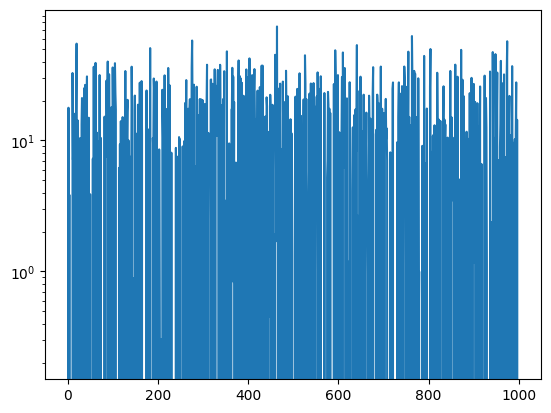

In [311]:
x = 20
plt.semilogy(Q[:k,x].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:])

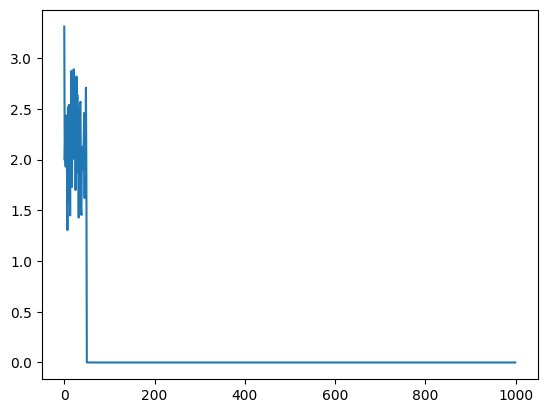

In [360]:
row_norms = []
for x in range(len(S)):
    temp = np.linalg.norm(Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S)[:,x])
    row_norms.append(temp)
plt.plot(row_norms)


In [364]:
np.linalg.norm(S[:k])

0.01

In [510]:
temp = Q[:k,:end].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:end] 
np.linalg.norm(temp), np.linalg.norm(temp-np.diag(np.diag(temp)))

(1414.1541525420814, 1063.971438361981)

0.002287382776345679
0.0021834684117109566
0.0031622776601683794


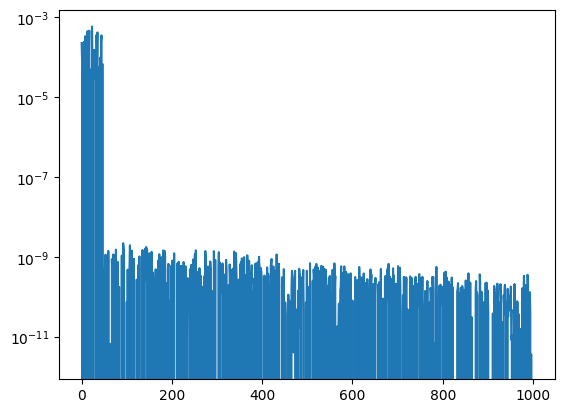

1.2211270283904972e-08
7.0082403364375925e-09
1e-08


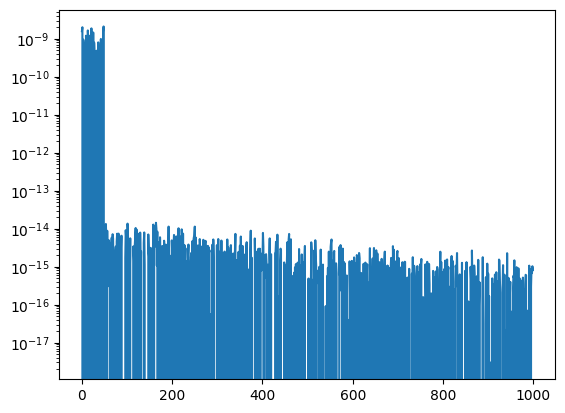

In [516]:
for x in range(end-1, end+1):
    print(np.linalg.norm(np.diag(S)[x,:] @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)[x,:]))
    print(np.linalg.norm(np.diag(S)[x,:] @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S) ))
    print(np.linalg.norm( np.diag(S)[x,:]))
    plt.semilogy((np.diag(S)[x,:] @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)[x,:]))
    plt.show()

In [507]:
S[x] * np.linalg.norm(S11_inv)

0.6933514899706777

In [ ]:
np.diag(S)[x,:] @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)[x,:]

In [341]:
np.sum(row_norms)

0.0004000000001363069

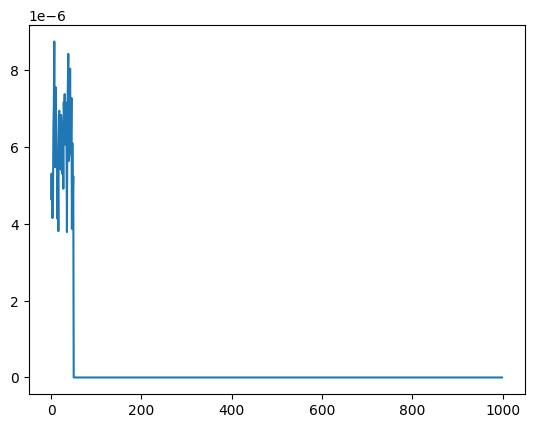

In [511]:
row_norms = []
for x in range(len(S)):
    temp = np.linalg.norm((np.diag(S)[x,:] @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)[x,:]))**2
    row_norms.append(temp)
plt.plot(row_norms)
plt.show()

# row_norms1 = []
# for x in range(len(S)):
#     temp = np.linalg.norm((np.diag(S)[x,:] @ Q[:k,:].T @ V11 @ np.diag(S11_inv) @ V11.T @ Q[:k,:] @ np.diag(S)))
#     row_norms1.append(temp)
# plt.plot(row_norms1)
# # plt.show()

# row_norms2 = []
# for x in range(len(S)):
#     temp = np.linalg.norm(np.diag(S)[x,:])
#     row_norms2.append(temp)
# plt.plot(row_norms2)
# plt.plot(np.array(row_norms2) + np.array(row_norms1), label="subtract")
# plt.legend()
# plt.show()



In [512]:
np.sum(np.array(row_norms[:end]))

0.00030000000070938695

In [485]:
# S_approx, S[:2*k]

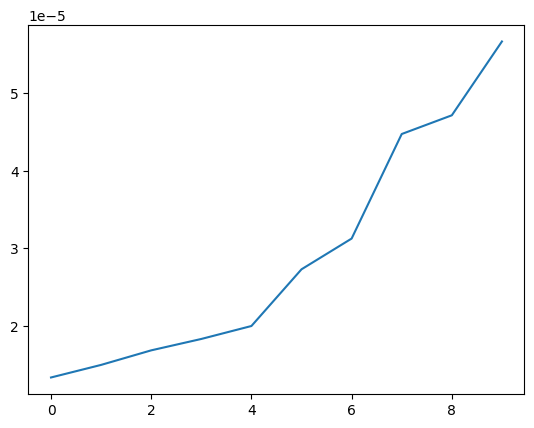

In [237]:
import matplotlib.pyplot as plt
rel_diff = np.abs(S_approx[:r] - S[:r]) / np.abs(S[:r])

plt.plot(np.arange(len(rel_diff)), rel_diff)
plt.show()

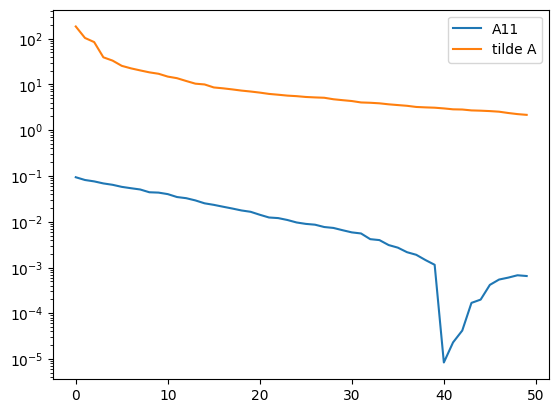

In [34]:
plt.semilogy(S11, label="A11")
plt.semilogy(S_G, label="tilde A")
plt.legend()

In [240]:
norm_list = [np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ Q[x,:].T) for x in range(len(S))]
norm_row_list = [np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S)) @ Q[x,:].T) for x in range(len(S))]
norm_row_S_list = [np.linalg.norm((np.diag(S)) @ Q[x,:].T) for x in range(len(S))]

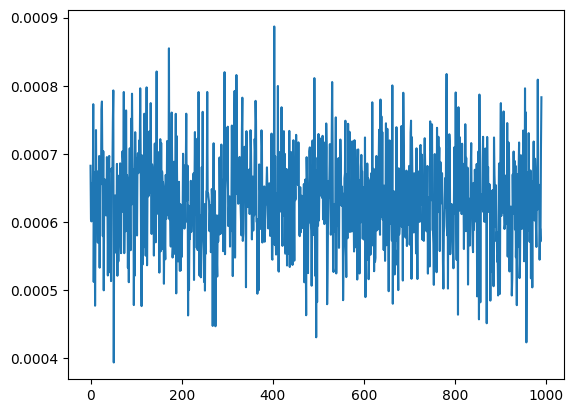

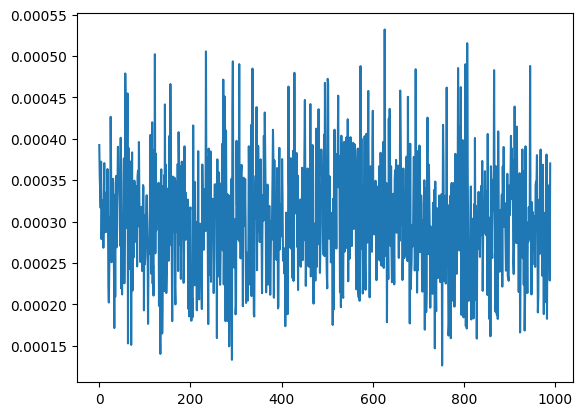

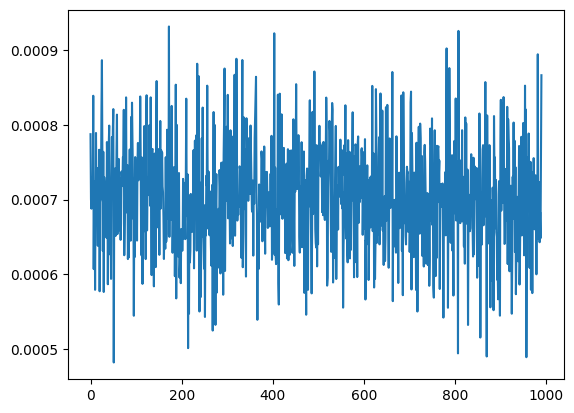

In [241]:
plt.plot(norm_list[k:])
plt.show()
plt.plot(norm_row_list[k:])
plt.show()
plt.plot(norm_row_S_list[k:])
plt.show()

In [242]:
np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ Q[k:,:].T),\
np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S)) @ Q[k:,:].T),\
np.linalg.norm((np.diag(S)) @ Q[k:,:].T)

(0.020000000003407667, 0.009743082902848713, 0.022247100434269407)

In [243]:
np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)))
# np.linalg.norm(Q[k:,:].T)

0.02000000000340766

In [244]:
from scipy import stats
pearson_r, p_value = stats.pearsonr(norm_row_list[k:], norm_row_S_list[k:])
print(f"Pearson correlation coefficient: {pearson_r}, p-value: {p_value}")

Pearson correlation coefficient: 0.4502971770823612, p-value: 1.3558731676154598e-50


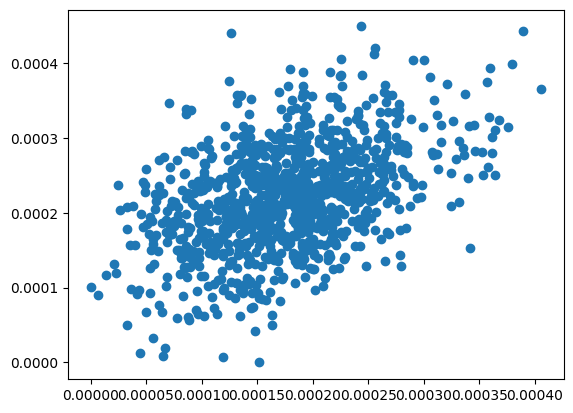

In [245]:
plt.scatter(norm_row_list[k:]-np.min(norm_row_list[k:]), norm_row_S_list[k:]-np.min(norm_row_S_list[k:]))
# plt.xlim(0.02, 0.16)
# plt.ylim(0.02, 0.16)
plt.show()

In [246]:
np.linalg.norm(17.48 / (n) * S), np.mean(norm_row_list[k:])

(0.0003908646824749571, 0.00030198412903196153)

In [247]:
norm_list_2 = [np.linalg.norm((np.diag(S)[x,:] @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S))) for x in range(len(S))]
norm_row_list_2 = [np.linalg.norm((np.diag(S)[x,:] @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S))) for x in range(len(S))]
norm_row_S_list_2 = [np.linalg.norm((np.diag(S)[x,:])) for x in range(len(S))]

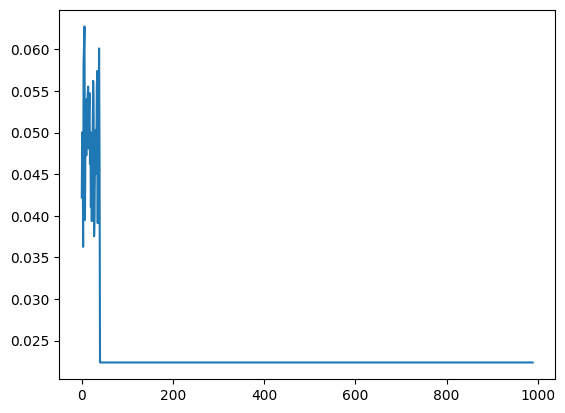

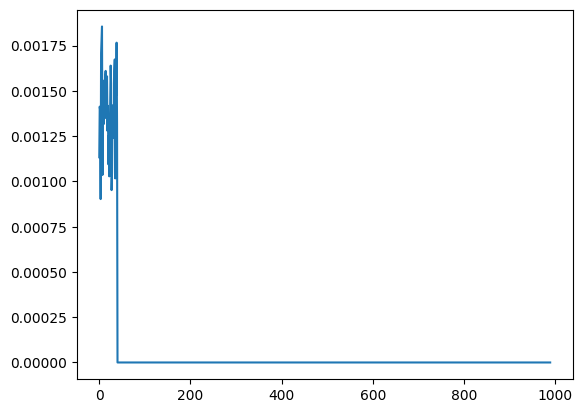

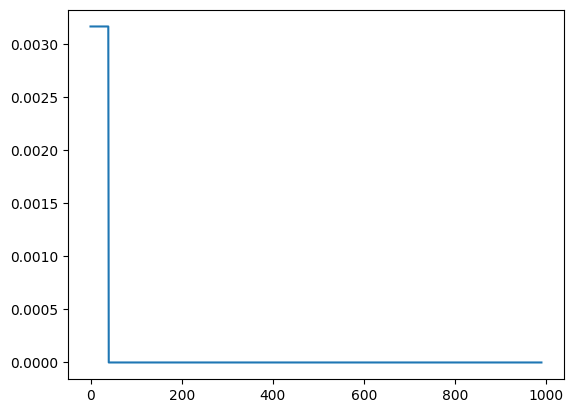

In [248]:
plt.plot(norm_list_2[k:])
plt.show()
plt.plot(norm_row_list_2[k:])
plt.show()
plt.plot(norm_row_S_list_2[k:])
plt.show()

In [249]:
Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:]

array([[ 96.74512321,  39.21274741, -27.90321023, ...,   8.20475852,
         80.50093724, -21.99511561],
       [ 39.21274741,  46.50674207,   2.94412327, ...,  -8.20130352,
         33.23080518,  -3.10542256],
       [-27.90321023,   2.94412327,  59.16452241, ..., -13.39418565,
          7.67876942,  -1.16606005],
       ...,
       [  8.20475852,  -8.20130352, -13.39418565, ...,  78.17971849,
         30.75270607,   0.99638449],
       [ 80.50093724,  33.23080518,   7.67876942, ...,  30.75270607,
        150.6141375 , -73.32499843],
       [-21.99511561,  -3.10542256,  -1.16606005, ...,   0.99638449,
        -73.32499843,  99.2186301 ]])

In [250]:
np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S))),\
np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S)) ),\
np.linalg.norm((np.diag(S)))

(0.02000000000340766, 0.009999709332763838, 0.022360679775455212)

In [251]:
from scipy import stats
pearson_r, p_value = stats.pearsonr(norm_row_list_2[k:], norm_row_S_list_2[k:])
print(f"Pearson correlation coefficient: {pearson_r}, p-value: {p_value}")

Pearson correlation coefficient: 0.9851753767009102, p-value: 0.0


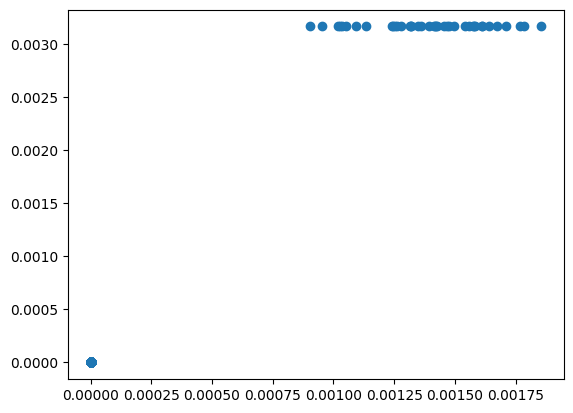

In [252]:
plt.scatter(norm_row_list_2[k:]-np.min(norm_row_list_2[k:]), norm_row_S_list_2[k:]-np.min(norm_row_S_list_2[k:]))
# plt.xlim(0.02, 0.16)
# plt.ylim(0.02, 0.16)
plt.show()

<Axes: ylabel='Count'>

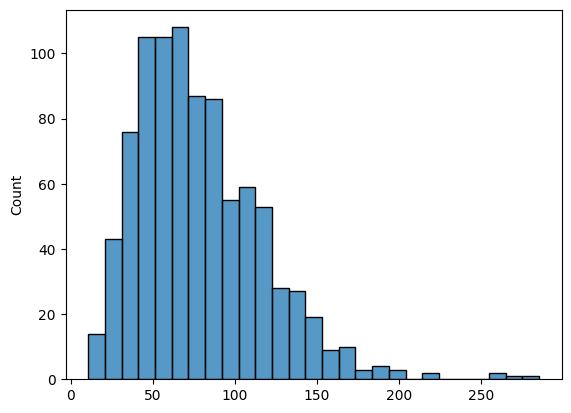

In [253]:
import seaborn as sns
sns.histplot(np.diag(Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:])[10*k:])

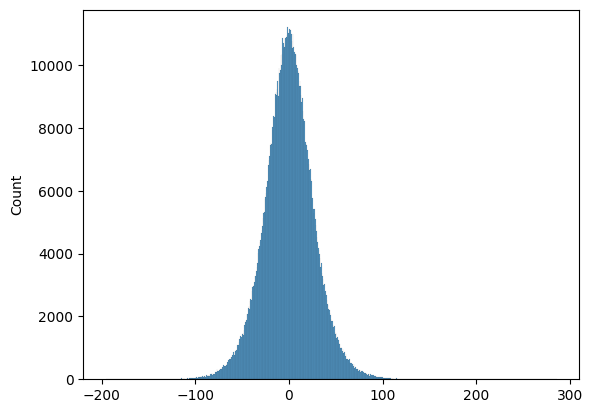

(0.08331437884568496, 27.07793157429189)

In [254]:
matrix_elements = (Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:]).reshape(-1)
sns.histplot(matrix_elements)
plt.show()
matrix_elements.mean(), matrix_elements.std()

<Axes: ylabel='Count'>

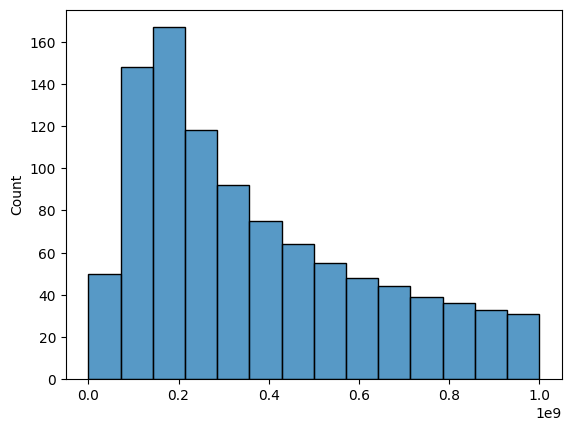

In [255]:
sns.histplot(1/S)

In [ ]:
1/S

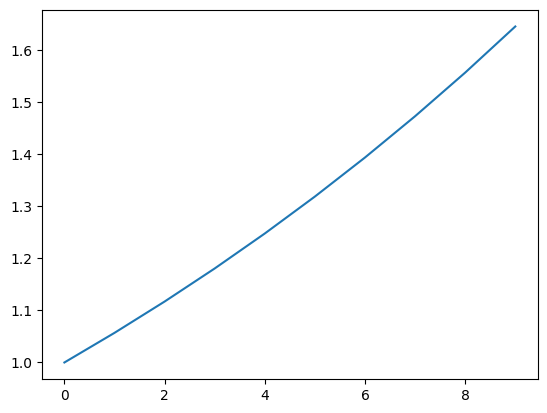

In [214]:
plt.plot(1/S[:k])

In [208]:
np.sum(np.diag(Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:])) 

780.0519553373651

In [209]:
np.sum(1/S11)

780.0519553373653

In [173]:
np.sum(S11)

0.21208039275655327

In [181]:
np.sum((Q[:k,:]**2).sum(axis=0) * S)

0.21208039275655308

In [210]:
S11

array([0.03769468, 0.02914495, 0.02551462, 0.02063887, 0.01779544,
       0.01264177, 0.0064534 , 0.01021451, 0.00884044, 0.00767485])

In [197]:
(np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) 

array([[-6.04468776e-01, -2.82661159e-02,  8.03511441e-02, ...,
        -4.83676070e-25, -3.74881955e-25, -5.54286283e-26],
       [-2.82661159e-02, -6.84052933e-01, -3.26665199e-02, ...,
         2.42799404e-25,  8.43898360e-26, -8.28747975e-26],
       [ 8.03511441e-02, -3.26665199e-02, -5.68391273e-01, ...,
        -1.36464236e-25,  3.08934878e-28,  5.11369597e-26],
       ...,
       [-4.83676070e-25,  2.42799404e-25, -1.36464236e-25, ...,
        -1.11698682e-24,  8.96605196e-49,  5.98271819e-50],
       [-3.74881955e-25,  8.43898360e-26,  3.08934878e-28, ...,
         8.96605196e-49, -1.05687597e-24,  3.35416413e-49],
       [-5.54286283e-26, -8.28747975e-26,  5.11369597e-26, ...,
         5.98271819e-50,  3.35416413e-49, -1.00000000e-24]])

In [65]:
np.linalg.svd(U_G.T @ Q[:,:r], compute_uv=False)

array([0.97161818, 0.94883704, 0.91097328, 0.83180177, 0.76338638,
       0.71064009, 0.66570237, 0.4694857 , 0.32226749, 0.01643921])

In [20]:
u, s, v = np.linalg.svd(Q[:k,:], compute_uv=True)

In [54]:
np.linalg.norm(np.abs(S_approx[:r] - S[:r]) / np.abs(S[:r])) 

1.4290235442971002

In [1157]:
# np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) @ v[:, 1]

In [55]:
sum_norm = 0# np.zeros(S.shape[0])
sum_norms = []
for i in range(k, v.shape[0]):
    norm = np.linalg.norm( (np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ v[i, :] )**2
    sum_norm += norm
    sum_norms.append(norm)
np.sqrt(sum_norm)

2.4382150596228667

In [66]:
np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ v[k+0, :]) ** 2

0.2284612447734429

/opt/anaconda/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log10
  """
/opt/anaconda/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in log10
  """
/opt/anaconda/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  
/opt/anaconda/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in log10
  
/opt/anaconda/lib/python3.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in log10
  import sys
/opt/anaconda/lib/python3.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in log10
  import sys


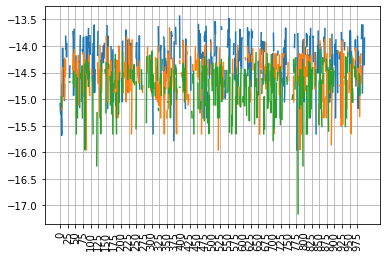

In [1185]:
(np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ v[k+0, :]
# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ v[k+0, :]))
# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ v[k+10, :]))
# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ v[k+20, :]))
plt.plot(np.log10((Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] - np.zeros(S.shape[0])) @ v[k+0, :]))
plt.plot(np.log10((Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] - np.zeros(S.shape[0])) @ v[k+10, :]))
plt.plot(np.log10((Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] - np.zeros(S.shape[0])) @ v[k+20, :]))
plt.xticks(np.arange(0, len(S), 25), rotation=90)
plt.grid()

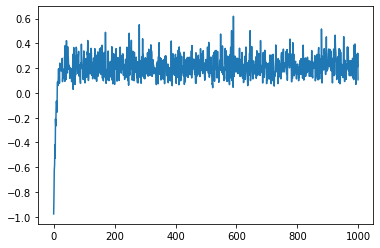

In [1281]:
# np.linalg.norm((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)))
# np.linalg.norm((Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.eye(n)))
norms = np.array([(Q[:k,x].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.eye(n)[x,:])**2 for x in range(n)])
# np.sqrt(np.sum(norms))
plt.plot(np.log10(np.sqrt(np.sum(norms,axis=0))))
# norms.shape

In [1280]:
x = 200
Q[:k,x].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.eye(n)[x,:]

array([-3.17304110e-01, -5.51969873e-02,  1.99203757e-01, -1.42024701e-01,
        3.30671538e-01,  9.10777750e-02, -1.56456724e-01, -1.57332308e-01,
       -7.95904598e-02,  1.58164528e-01, -2.64014544e-03,  4.94275391e-02,
        6.74598531e-02, -1.43110183e-02,  1.03970480e-02, -4.33616238e-02,
        4.02359732e-02, -1.21001053e-02,  4.83576704e-03,  9.10018468e-03,
        1.68679290e-02, -2.29656534e-03, -4.77550013e-03,  5.26740961e-03,
        5.44590220e-03, -6.13655436e-03,  3.21251268e-03,  2.22061715e-03,
       -1.23221065e-04,  4.62487734e-04,  1.32116414e-03,  4.03740295e-04,
        3.75670694e-04, -2.77927303e-04,  2.60342725e-04,  4.45236007e-04,
        1.92595120e-04,  1.07172870e-04,  1.35105945e-04, -7.15188555e-05,
        2.81633172e-06, -1.12078210e-04, -5.64506457e-05,  8.55928200e-05,
        6.99920793e-05, -3.41589500e-05, -2.05769929e-05, -3.10879096e-05,
       -2.93032137e-06, -1.63662004e-05, -1.13057267e-06,  9.66864013e-06,
       -8.27028537e-06, -

In [1274]:
np.sum(norms,axis=0)

array([138.11692308, 250.16912243, 355.98074781,  93.91599087,
       144.84190529, 138.32891672,  97.72960491, 188.34951197,
       165.99322188,  67.28086084,  90.55296427,  92.14505702,
        37.84276619,  19.15107335,   2.68897257,   2.18297935,
        13.05583866,   3.82105783,   5.69181048,   2.16968629,
         2.30814494,   1.99371076,   1.41545303,   1.33504717,
         1.33513336,   1.24018507,   1.16197865,   1.00383199,
         1.01348748,   0.99840073,   0.99730119,   0.99672417,
         0.99881488,   0.99783647,   0.99676555,   0.99732831,
         0.9955877 ,   0.99919601,   0.99589598,   0.99930495,
         0.99960944,   0.99947939,   0.99755213,   0.9982945 ,
         0.99954947,   0.99974348,   0.99889083,   0.99965207,
         0.99967456,   0.99977734,   0.99968893,   0.9998128 ,
         0.99988589,   0.99993466,   0.9998903 ,   0.99988874,
         0.99994052,   0.99992645,   0.99982179,   0.99995685,
         0.99983545,   0.99996492,   0.99989724,   0.99

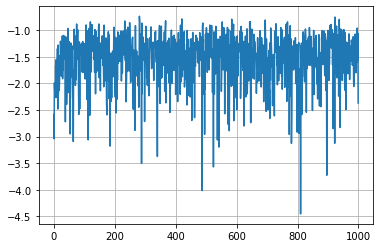

In [1249]:
e_i = np.zeros((n,1))
e_i[3,0] = 1

# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ Q[k+0,:].T))
# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ Q[k+10,:].T))
# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ Q[k+20,:].T))
plt.plot(np.log10(np.abs( (Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.eye(S.shape[0])) @ Q[k,:].T)))
# plt.plot(np.log10(( (Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.eye(S.shape[0])) @ Q[k+10,:].T)))
# plt.plot(np.log10(( (Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.eye(S.shape[0])) @ Q[k+20,:].T)))
# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] - np.eye(S.shape[0])) @ Q[k+0,:].T))
# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] - np.eye(S.shape[0])) @ Q[k+10,:].T))
# plt.plot(np.log10((np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] - np.eye(S.shape[0])) @ Q[k+20,:].T))
# plt.xticks(np.arange(0, len(S), 25), rotation=90)
plt.grid()
plt.show()

In [68]:
e_i.T @ (Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.eye(S.shape[0])) @ Q[k,:].T

NameError: name 'e_i' is not defined

In [1224]:
V11 @ np.diag(1/S11) @ V11.T @ Q[k+0,:].T

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1000 is different from 10)

In [1093]:
np.linalg.norm( (np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ v )

0.41866803178113843

In [1067]:
( (np.diag(S) @ Q[:k,:].T @ V11 @ np.diag(1/S11) @ V11.T @ Q[:k,:] @ np.diag(S) - np.diag(S)) @ v ).shape

(1000, 1000)

In [844]:
S_approx, S[:r]

(array([0.76097073, 0.72103586, 0.58838664, 0.49804438, 0.44570443,
        0.35960192, 0.35706007, 0.27398445, 0.22412958, 0.17987928]),
 array([1.        , 0.91029818, 0.82864277, 0.75431201, 0.68664885,
        0.62505519, 0.5689866 , 0.51794747, 0.47148664, 0.42919343]))

In [866]:
U_G[10:20, :] @ np.diag(S_approx) @ U_G[10:20, :].T 

array([[ 7.80955742e-03, -1.14021234e-03,  1.13781073e-03,
        -4.08261579e-03,  1.66174404e-03,  2.63872142e-03,
        -1.30654071e-03, -3.02560792e-03,  4.01244397e-03,
         3.09534016e-04],
       [-1.14021234e-03,  3.88296371e-03, -1.70433837e-03,
         9.49422924e-04, -1.53383081e-03, -1.37183825e-04,
         1.23337505e-03,  3.28214595e-04,  1.49722583e-04,
        -1.84885456e-03],
       [ 1.13781073e-03, -1.70433837e-03,  7.74423512e-03,
         2.07643078e-03,  1.62045318e-03,  3.36766731e-04,
        -1.36598861e-03, -1.48276605e-03, -3.31613699e-04,
         2.89133410e-03],
       [-4.08261579e-03,  9.49422924e-04,  2.07643078e-03,
         5.90337216e-03, -9.00305536e-05,  4.12310446e-04,
        -1.81241833e-04,  2.42426483e-03, -1.51147210e-03,
         2.03272364e-03],
       [ 1.66174404e-03, -1.53383081e-03,  1.62045318e-03,
        -9.00305536e-05,  4.84378057e-03,  2.63494243e-04,
        -1.42621627e-03,  2.41666343e-03, -4.45977824e-03,
         2.

In [865]:
A[10:20, 10:20]

array([[ 0.01244694, -0.00078468, -0.0001913 , -0.0074799 ,  0.00259266,
         0.002566  , -0.0029348 , -0.00208952,  0.00519267,  0.00089665],
       [-0.00078468,  0.00992228, -0.00289299,  0.00255956, -0.00221555,
        -0.00154092,  0.00268657,  0.00051188,  0.0005411 , -0.00241488],
       [-0.0001913 , -0.00289299,  0.01706662,  0.00360122,  0.00166272,
        -0.00025713, -0.00397706, -0.00331066, -0.0034068 ,  0.00493055],
       [-0.0074799 ,  0.00255956,  0.00360122,  0.01872488, -0.00210413,
         0.00356222,  0.00299565,  0.0018892 , -0.00525738, -0.00173736],
       [ 0.00259266, -0.00221555,  0.00166272, -0.00210413,  0.01038234,
         0.00075649, -0.00247515,  0.00278169, -0.00403546,  0.00530659],
       [ 0.002566  , -0.00154092, -0.00025713,  0.00356222,  0.00075649,
         0.00813202, -0.00161026,  0.00053003,  0.00239746, -0.00098205],
       [-0.0029348 ,  0.00268657, -0.00397706,  0.00299565, -0.00247515,
        -0.00161026,  0.01472334, -0.00042204

In [858]:
inside = U_G[:50, :10].T @ A11_temp_inverted @ U_G[:50, :10]
np.linalg.norm(inside - np.diag(np.diag(inside)))

6.046162571508396e-10

In [863]:
 Q[:50, :10].T  @ Q[:50, :10]

array([[ 5.48013784e-02,  8.12832938e-04,  2.56729690e-03,
        -8.05099380e-03,  9.55091914e-03,  1.38180182e-02,
        -2.33494029e-03,  3.77844931e-03,  3.06008591e-03,
        -5.79442560e-03],
       [ 8.12832938e-04,  4.93413340e-02, -2.88714710e-03,
        -1.42745454e-03, -3.62357288e-03,  7.37998587e-03,
         5.75626435e-03, -9.09198640e-03, -8.12126496e-03,
         1.31319659e-03],
       [ 2.56729690e-03, -2.88714710e-03,  3.20314777e-02,
         4.35439759e-03, -5.64365063e-03, -8.25659959e-04,
        -4.87207991e-03,  4.83155508e-03,  1.85905639e-03,
        -4.57702380e-03],
       [-8.05099380e-03, -1.42745454e-03,  4.35439759e-03,
         5.11553074e-02, -4.59552347e-03,  8.67770011e-04,
         3.33387617e-03,  7.58796825e-03,  1.42921705e-02,
         8.93835468e-03],
       [ 9.55091914e-03, -3.62357288e-03, -5.64365063e-03,
        -4.59552347e-03,  4.65148335e-02,  4.33540525e-03,
        -6.03701561e-03,  2.36998743e-03,  8.28657566e-03,
         3.

In [852]:
1/np.diag(Q[:50, :10].T @ A11_temp_inverted @ Q[:50, :10])

array([1.        , 0.91029818, 0.82864277, 0.75431201, 0.68664885,
       0.62505519, 0.5689866 , 0.51794747, 0.47148664, 0.42919343])

In [840]:
verify_a_orthogonality(U_G[:50], A11_temp_inverted, tol=1e-10)

1.9496478601968284e-10

In [848]:

S11_temp, V11_temp = np.linalg.eig(A[:50, :50])
A11_temp_inverted = V11_temp @ np.diag(1/S11_temp) @ V11_temp.T
Q_temp, R_temp = a_orthogonal_qr(U_G[:50, :], A11_temp_inverted)

In [867]:
S11_temp, S11

(array([6.94818557e-02, 5.73855468e-02, 5.01714328e-02, 4.14776002e-02,
        3.97205925e-02, 3.16666389e-02, 2.88319250e-02, 2.54376717e-02,
        2.35091832e-02, 2.25506448e-02, 1.70373182e-02, 1.50033732e-02,
        1.34358988e-02, 1.28438820e-02, 1.18583819e-02, 1.04488055e-02,
        9.10693818e-03, 8.17729520e-03, 6.80568937e-03, 5.85690193e-03,
        5.77301854e-03, 4.73144248e-03, 3.68616169e-03, 3.46304774e-03,
        2.99417360e-03, 2.54747689e-03, 2.28080635e-03, 2.16107183e-03,
        1.89999777e-03, 1.66285299e-03, 1.43815107e-03, 1.24844425e-03,
        1.01066147e-03, 8.96336527e-04, 8.13825648e-04, 6.18445124e-04,
        5.38969327e-04, 4.16377116e-04, 3.62900287e-04, 2.65170831e-04,
        2.34693074e-04, 2.16847451e-04, 1.17230184e-04, 1.05590971e-04,
        4.50609549e-05, 3.27125707e-05, 2.21204391e-05, 3.53087698e-09,
        2.57183356e-06, 9.36707272e-06]),
 array([0.02870467, 0.02107514, 0.01707659, 0.01047785, 0.00948398,
        0.00168895, 0.0069

In [861]:
V11_temp.shape, V11.shape

((50, 50), (10, 10))

In [838]:
UG_temp = U_G.copy()
UG_temp[:50] = Q_temp
UG_temp, _ = np.linalg.qr(UG_temp)
s = np.linalg.svd(UG_temp[:,:].T @ Q[:, :r], compute_uv=False)
s

array([0.99298804, 0.98605634, 0.97924358, 0.95026217, 0.90162683,
       0.85460713, 0.83535783, 0.6215347 , 0.48944472, 0.02759996])

In [839]:
verify_a_orthogonality(UG_temp[:50], A11_temp_inverted, tol=1e-10)

0.008044219053260488

In [694]:
s = np.linalg.svd(U_G[:20,:].T @ Q[:20, :], compute_uv=False)
s

array([0.66812658, 0.62052867, 0.44379629, 0.2763966 , 0.24607298,
       0.22124406, 0.20028864, 0.18711024, 0.17354515, 0.13854138,
       0.13026812, 0.12415721, 0.11257878, 0.10534674, 0.08878207,
       0.07810195, 0.06582938, 0.04934584, 0.03549521, 0.01746246])

In [695]:
s = np.linalg.svd(Q_temp.T @ Q[:100, :], compute_uv=False)
s

array([3.17627302e-01, 1.79125255e-01, 9.92043728e-02, 5.61748071e-02,
       2.75633991e-02, 1.39950971e-02, 8.19663765e-03, 3.83985300e-03,
       2.24119503e-03, 1.54707677e-03, 6.99667443e-04, 3.77786173e-04,
       2.04484588e-04, 1.08338835e-04, 4.76749762e-05, 2.78746275e-05,
       9.79716887e-06, 5.54151535e-06, 4.92912349e-06, 4.86592716e-06])

In [673]:
Q_temp.shape

(20, 10)

In [658]:
U_G.shape

(1000, 10)

In [652]:
A11_temp_inverted.shape

(20, 20)

In [649]:
# A12, U_G[:k, :] @ np.diag(S_approx) @ U_G[k:, :].T

In [24]:

np.linalg.norm(A[r:, r:] - A[:k, r:].T @ V11[:,:] @ np.diag((1/(S11))) @ V11[:,:].T @ A[:k, r:]),\
np.linalg.norm(A[:r, :r] - U_G[:r, :] @ np.diag(S_approx) @ U_G[:r, :].T),\
np.linalg.norm(A[:r, r:] - U_G[:r, :] @ np.diag(S_approx) @ U_G[r:, :].T),\
np.linalg.norm(Q[r:, :r] @ np.diag(S[:r]) @ Q[r:, :r].T - U_G[r:, :] @ np.diag(S[:r]) @ U_G[r:,:].T)

(64.95300631422504,
 8.369512106788996e-14,
 6.919805940686012e-14,
 28.130899259183582)

In [835]:
U_G[:50, :].T @ A11_temp_inverted @ U_G[:50, :]

array([[ 1.31411098e+00, -7.29194856e-11,  8.46719282e-11,
         8.68235729e-11, -1.42838295e-10, -8.44899662e-12,
         2.97417161e-11, -1.94964786e-10, -1.32036688e-11,
         2.00130409e-11],
       [-4.45545105e-12,  1.38689357e+00,  9.98283254e-11,
         1.21050479e-10, -1.18565185e-12,  7.58726472e-11,
        -1.03291799e-10, -2.90351395e-11,  1.21561717e-10,
        -8.57802794e-11],
       [-4.24530717e-11,  4.31742781e-11,  1.69956272e+00,
         1.32025558e-12, -9.36496221e-12, -8.02256320e-11,
         1.64693685e-11,  2.52022420e-11, -4.58220526e-12,
        -1.37876762e-11],
       [-6.65308720e-11,  4.25741160e-11, -3.22721858e-12,
         2.00785320e+00,  3.54037726e-11, -6.35070738e-11,
         5.27589763e-11,  8.57318110e-11, -5.69756322e-11,
        -2.34062853e-13],
       [ 4.84044622e-11, -6.69430767e-11, -3.75824879e-12,
         2.50452708e-11,  2.24363937e+00,  9.78149655e-11,
         1.29083956e-11, -5.16622080e-12,  2.03423872e-11,
        -3.

1.7569287638241462, 1.4639645703478845
1.05482394333414, 1.0242985868995917
array([0.28319319, 0.27106756, 0.25041712, 0.23495387, 0.23346912,
       0.22574172, 0.20654274, 0.19588863, 0.17489917, 0.16304918])
       
array([0.37471248, 0.36112098, 0.33622364, 0.32104813, 0.29391736,
       0.27158162, 0.27107937, 0.25587107, 0.23490942, 0.2304686 ,
       0.22138997, 0.21486816, 0.20055805, 0.19605477, 0.18598325,
       0.17183532, 0.16420435, 0.15716296, 0.14095532, 0.12879621])

In [1000]:
np.linalg.norm(np.diag(S) @ Q[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ Q[:k, :] @ np.diag(S))

2.606256151627643

In [1001]:
np.linalg.norm(np.diag(S) - np.diag(S) @ Q[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ Q[:k, :] @ np.diag(S)), np.linalg.norm(np.diag(S[k:]))

(2.062521271485199, 2.062521271485199)

In [986]:
np.linalg.norm(Q[k:, :] @ (np.diag(S) - np.diag(S) @ Q[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ Q[:k, :] @ np.diag(S)) @ Q[k:, :].T)

2.062521271485199

In [987]:
np.linalg.norm(Q[k:, :] @ np.diag(S) @ Q[k:, :].T - Q[k:, :] @  np.diag(S) @ Q[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ Q[:k, :] @ np.diag(S) @ Q[k:, :].T)

2.062521271485199

In [988]:
np.linalg.norm(A[k:, :k] - Q[k:, :] @  np.diag(S) @ Q[:k, :].T)

0.0

In [928]:
np.linalg.norm(np.eye(S.shape[0]) - Q[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ Q[:k, :] @ np.diag(S))

36.591339339822234

In [922]:
import sys
import numpy
# with np.printoptions(threshold=sys.maxsize):
print(np.diag(S) @ Q[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ Q[:k, :] @ np.diag(S))

[[ 4.01892508e-01 -3.00678949e-02  8.59327338e-02 ...  3.58685169e-14
  -8.05911501e-14 -1.41001982e-13]
 [-3.00678949e-02  4.19993852e-01 -5.76116895e-02 ...  1.36099777e-13
  -1.01885621e-14 -2.44136728e-13]
 [ 8.59327338e-02 -5.76116895e-02  2.92676439e-01 ...  6.76708716e-14
   6.18249620e-14  2.12526914e-14]
 ...
 [ 3.58685169e-14  1.36099777e-13  6.76708716e-14 ...  8.31961384e-25
   2.39858173e-25 -5.63258841e-26]
 [-8.05911501e-14 -1.01885621e-14  6.18249620e-14 ...  2.39858173e-25
   1.65066483e-24  1.11449059e-25]
 [-1.41001982e-13 -2.44136728e-13  2.12526914e-14 ... -5.63258841e-26
   1.11449059e-25  4.04633791e-25]]


In [949]:
V11 @ np.diag((1/(S11))) @ V11.T @ Q[:k, :] @ np.diag(S) @ v[k+1, :]

array([ 1.17886183, -1.22518089, -0.04206217, -0.51066834, -0.3241946 ,
       -0.95952551,  1.81626827, -0.65807005,  0.26221722, -1.96246812])

In [ ]:
Q[:k, :]

In [941]:
u, s, v = np.linalg.svd(Q[:k,:])
Q[:k,:] @ v[k+1, :]

array([-9.36750677e-17,  8.67361738e-18,  3.98986399e-17,  1.43114687e-17,
        3.12250226e-17,  2.16840434e-17, -1.38777878e-17,  2.51534904e-17,
        9.54097912e-18, -3.46944695e-18])

In [926]:
np.linalg.norm(Q[:k,:].T)

3.16227766016838

In [199]:
U_G[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ U_G[:k, :]

array([[ 5.00894134e-01, -2.47371568e-15,  2.41473508e-15,
         1.82319437e-15],
       [-2.22044605e-15,  2.34306826e+00,  1.66533454e-14,
         1.66533454e-14],
       [ 1.77635684e-15,  1.50990331e-14,  1.08135282e+01,
         1.56763491e-13],
       [ 2.66453526e-15,  1.77635684e-14,  1.58983937e-13,
         4.89825024e+01]])

In [208]:
U_G[:k, :].T @ V11

array([[-0.88839494, -0.04943267,  0.0170236 ,  0.00414354],
       [-0.38891599,  0.59546133, -0.12948021, -0.02932304],
       [-0.17598257, -0.68220068, -0.55738747, -0.10571326],
       [-0.04372462, -0.06843731,  0.41404092, -0.85300088]])

In [203]:
1/S11, 1/S_approx

(array([ 0.60859422,  5.01651543, 25.02230534, 61.39036254]),
 array([ 0.50089413,  2.34306826, 10.81352824, 48.98250241]))

In [185]:
np.linalg.norm(np.diag(S) - np.diag(S) @ np.diag(np.diag(inside)) @ np.diag(S))

0.4386896092894601

In [182]:
U_G, Q, U_G.shape, Q.shape

(array([[-0.56397746,  0.60395046],
        [-0.11189825, -0.54146198],
        [ 0.31789892,  0.43790106],
        [-0.54763363, -0.03659202],
        [-0.50260991, -0.30083049],
        [ 0.12581402, -0.24180047]]),
 array([[-0.52997187, -0.2604647 , -0.49367409,  0.33004842,  0.48163962,
         -0.25819599],
        [-0.1056737 , -0.03781007,  0.14840741, -0.73235896,  0.17956723,
         -0.62990847],
        [ 0.38409646, -0.45238775, -0.66960051, -0.37294989, -0.14740502,
          0.19654653],
        [-0.59084622,  0.48781223, -0.32700357, -0.32984936, -0.34674198,
          0.27744916],
        [-0.44722949, -0.66295101,  0.41963205, -0.16912946, -0.0999127 ,
          0.38184207],
        [ 0.10639233,  0.2204746 ,  0.05360881, -0.27968089,  0.76409299,
          0.52453619]]),
 (6, 2),
 (6, 6))

In [183]:
np.linalg.norm(np.diag(S[:k]) - np.diag(S[:k]) @ U_G[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ U_G[:k, :] @ np.diag(S[:k]))

3.8557326703950614

In [184]:
inside = Q[:k, :].T @ V11 @ np.diag((1/(S11))) @ V11.T @ Q[:k, :]
inside

array([[ 0.4677288 ,  0.21811734,  0.23023987,  0.37305089, -0.49459775,
         0.70931026],
       [ 0.21811734,  0.11202561,  0.2875442 , -0.40863276, -0.16967654,
        -0.09142903],
       [ 0.23023987,  0.2875442 ,  3.2619629 , -9.99745693,  0.8220152 ,
        -7.02898239],
       [ 0.37305089, -0.40863276, -9.99745693, 33.21811547, -3.83971682,
        24.42296326],
       [-0.49459775, -0.16967654,  0.8220152 , -3.83971682,  0.88356432,
        -3.24678687],
       [ 0.70931026, -0.09142903, -7.02898239, 24.42296326, -3.24678687,
        18.36477912]])

In [186]:
np.diag(inside)

array([ 0.4677288 ,  0.11202561,  3.2619629 , 33.21811547,  0.88356432,
       18.36477912])

In [187]:
inside - np.diag(np.diag(inside))

array([[ 0.        ,  0.21811734,  0.23023987,  0.37305089, -0.49459775,
         0.70931026],
       [ 0.21811734,  0.        ,  0.2875442 , -0.40863276, -0.16967654,
        -0.09142903],
       [ 0.23023987,  0.2875442 ,  0.        , -9.99745693,  0.8220152 ,
        -7.02898239],
       [ 0.37305089, -0.40863276, -9.99745693,  0.        , -3.83971682,
        24.42296326],
       [-0.49459775, -0.16967654,  0.8220152 , -3.83971682,  0.        ,
        -3.24678687],
       [ 0.70931026, -0.09142903, -7.02898239, 24.42296326, -3.24678687,
         0.        ]])

In [188]:
np.diag(S) @ inside 

array([[ 9.35457603e-01,  4.36234686e-01,  4.60479743e-01,
         7.46101773e-01, -9.89195501e-01,  1.41862053e+00],
       [ 9.49410879e-02,  4.87619770e-02,  1.25160885e-01,
        -1.77867742e-01, -7.38560057e-02, -3.97967962e-02],
       [ 2.18111492e-02,  2.72397197e-02,  3.09013200e-01,
        -9.47081943e-01,  7.78713787e-02, -6.65871566e-01],
       [ 7.69130618e-03, -8.42490884e-03, -2.06120680e-01,
         6.84868221e-01, -7.91646362e-02,  5.03535832e-01],
       [-2.21931103e-03, -7.61356123e-04,  3.68846683e-03,
        -1.72292047e-02,  3.96464406e-03, -1.45686669e-02],
       [ 6.92685804e-04, -8.92861608e-05, -6.86424062e-03,
         2.38505501e-02, -3.17069030e-03,  1.79343546e-02]])

In [189]:
1/S

array([5.00000000e-01, 2.29739671e+00, 1.05560633e+01, 4.85029301e+01,
       2.22860944e+02, 1.02400000e+03])

In [190]:
S

array([2.00000000e+00, 4.35275282e-01, 9.47322854e-02, 2.06173111e-02,
       4.48710295e-03, 9.76562500e-04])

In [635]:
import numpy as np

def a_orthogonal_qr(X, A):
    """
    Compute the A-orthogonal QR factorization of matrix X with respect to matrix A.
    
    Parameters:
    X : ndarray of shape (n, m)
        Input matrix to be factored
    A : ndarray of shape (n, n)
        Symmetric positive definite matrix defining the inner product
        
    Returns:
    Q : ndarray of shape (n, m)
        Matrix with A-orthogonal columns (Q.T @ A @ Q is diagonal)
    R : ndarray of shape (m, m)
        Upper triangular matrix
    """
    n, m = X.shape
    Q = np.zeros((n, m))
    R = np.zeros((m, m))
    
    # First column
    R[0,0] = np.sqrt(X[:,0].T @ A @ X[:,0])  # A-norm
    Q[:,0] = X[:,0] / R[0,0]
    
    # Remaining columns
    for j in range(1, m):
        # Current column
        q = X[:,j].copy()
        
        # A-orthogonalize against previous columns
        for i in range(j):
            R[i,j] = Q[:,i].T @ A @ X[:,j]
            q = q - R[i,j] * Q[:,i]
        
        # Compute A-norm and normalize
        R[j,j] = np.sqrt(q.T @ A @ q)
        if R[j,j] < 1e-10:  # Check for numerical stability
            raise ValueError("Matrix is rank deficient or A is not positive definite")
        Q[:,j] = q / R[j,j]
    
    return Q, R

def verify_a_orthogonality(Q, A, tol=1e-10):
    """
    Verify that Q has A-orthogonal columns.
    Returns the maximum absolute value of off-diagonal elements in Q.T @ A @ Q.
    """
    QtAQ = Q.T @ A @ Q
    off_diag = QtAQ - np.diag(np.diag(QtAQ))
    return np.max(np.abs(off_diag))

# Example usage:
if __name__ == "__main__":
    # Generate random test matrices
    n, m = 4, 3
    np.random.seed(42)
    x = np.random.randn(n, m)
    a = np.random.randn(n, n)
    a = a.T @ a  # Make A symmetric positive definite
    
    # Compute A-orthogonal QR factorization
    q, r = a_orthogonal_qr(x, a)
    
    # Verify results
    print("Original matrix X:\n", x)
    print("\nQ matrix:\n", q)
    print("\nR matrix:\n", r)
    print("\nReconstruction error:", np.max(np.abs(x - q @ r)))
    print("A-orthogonality check:", verify_a_orthogonality(q, a))
    print("\nQ^T A Q:\n", q.T @ a @ q)  # Should be diagonal

Original matrix X:
 [[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]]

Q matrix:
 [[ 0.076757   -0.19305784  0.88451387]
 [ 0.23535308 -0.40971228  0.5739195 ]
 [ 0.244035    0.54521061 -0.61886096]
 [ 0.08384154 -0.51084094  0.25090853]]

R matrix:
 [[ 6.47125539  0.81806221 -1.69803599]
 [ 0.          1.04143042  1.19292411]
 [ 0.          0.          1.1399799 ]]

Reconstruction error: 1.1102230246251565e-16
A-orthogonality check: 7.91033905045424e-16

Q^T A Q:
 [[ 1.00000000e+00  1.66533454e-16 -6.66133815e-16]
 [ 4.44089210e-16  1.00000000e+00  5.55111512e-16]
 [-7.91033905e-16  6.66133815e-16  1.00000000e+00]]


In [ ]:
a_orthogonal_qr()

In [521]:
import numpy as np
from numpy import linalg as LA

# Set random seed for reproducibility
np.random.seed(42)

# Set dimensions
k = 5  # Size of the original matrix A
n = 20  # Size of the transformed matrix B (n >> k)

# Generate a random orthogonal matrix V (k x k)
# We can use QR decomposition to generate an orthogonal matrix
random_matrix = np.random.randn(k, k)
V, _ = np.linalg.qr(random_matrix)

# Generate a diagonal matrix S with distinct eigenvalues
s_values = np.array([10.0, 7.0, 5.0, 3.0, 1.0])  # Eigenvalues
S = np.diag(s_values)

# Generate matrix A = VSV^T
A = V @ S @ V.T

# Verify A's eigenvalues match S
eigenvalues_A = np.linalg.eigvals(A)
eigenvalues_A = np.sort(eigenvalues_A)[::-1]  # Sort in descending order

print("Eigenvalues of S:")
print(s_values)
print("\nEigenvalues of A = VSV^T:")
print(eigenvalues_A)
print("\nDifference between eigenvalues of S and A:")
print(np.abs(s_values - eigenvalues_A))

# Generate a k x n matrix Q with orthonormal rows
# First create a random n x k matrix
random_tall = np.random.randn(n, k)
# Use QR decomposition to get orthonormal columns
Q_tall, _ = np.linalg.qr(random_tall, mode='complete')
# Transpose to get orthonormal rows
Q = Q_tall[:k,:]

# Verify QQ^T = I_k
QQT = Q @ Q.T
print("\nQQ^T (should be identity matrix):")
print(QQT)
print("Is QQ^T approximately I_k?", np.allclose(QQT, np.eye(k)))

# Verify column norms are <= 1
col_norms = np.linalg.norm(Q, axis=0)
print("\nMaximum column norm of Q:", np.max(col_norms))
print("All column norms <= 1?", np.all(col_norms <= 1))

# Compute B = Q^T VSV^T Q
B = Q.T @ V @ S @ V.T @ Q

# Calculate eigenvalues of B
eigenvalues_B = np.linalg.eigvals(B)
# Sort in descending order by absolute value (to handle potential numerical issues)
eigenvalues_B = np.sort(np.abs(eigenvalues_B))[::-1]

print("\nTop k eigenvalues of B = Q^T VSV^T Q:")
print(eigenvalues_B[:k])

# Compare the top k eigenvalues of B with the eigenvalues of S
print("\nDifference between eigenvalues of S and top k eigenvalues of B:")
print(np.abs(s_values - eigenvalues_B[:k]))

# Verify remaining eigenvalues are close to zero
print("\nRemaining eigenvalues of B (should be close to zero):")
print(eigenvalues_B[k:k+5], "...") # Show first 5 of the remaining

# Additional verification: Compute BB^T and its eigenvalues
BBT = B @ B.T
eigenvalues_BBT = np.linalg.eigvals(BBT)
eigenvalues_BBT = np.sort(np.abs(eigenvalues_BBT))[::-1]

# Compare with S^2
S_squared = S**2
eigenvalues_S_squared = np.diag(S_squared)

print("\nEigenvalues of S^2:")
print(eigenvalues_S_squared)
print("\nTop k eigenvalues of BB^T:")
print(eigenvalues_BBT[:k])
print("\nDifference between eigenvalues of S^2 and top k eigenvalues of BB^T:")
print(np.abs(eigenvalues_S_squared - eigenvalues_BBT[:k]))

Eigenvalues of S:
[10.  7.  5.  3.  1.]

Eigenvalues of A = VSV^T:
[10.  7.  5.  3.  1.]

Difference between eigenvalues of S and A:
[7.10542736e-15 4.44089210e-15 1.77635684e-15 4.44089210e-16
 1.33226763e-15]

QQ^T (should be identity matrix):
[[ 1.00000000e+00 -4.22543216e-17 -1.45659640e-16  3.69490477e-17
  -7.80360864e-17]
 [-4.22543216e-17  1.00000000e+00  4.26559267e-17 -4.25767146e-17
   1.18419069e-17]
 [-1.45659640e-16  4.26559267e-17  1.00000000e+00 -6.50794642e-17
   8.42571477e-17]
 [ 3.69490477e-17 -4.25767146e-17 -6.50794642e-17  1.00000000e+00
  -1.34685197e-17]
 [-7.80360864e-17  1.18419069e-17  8.42571477e-17 -1.34685197e-17
   1.00000000e+00]]
Is QQ^T approximately I_k? True

Maximum column norm of Q: 0.7620543573848287
All column norms <= 1? True

Top k eigenvalues of B = Q^T VSV^T Q:
[10.  7.  5.  3.  1.]

Difference between eigenvalues of S and top k eigenvalues of B:
[1.06581410e-14 1.77635684e-15 0.00000000e+00 0.00000000e+00
 3.33066907e-16]

Remaining eigenva

In [520]:
random_tall = np.random.randn(n, k)
# Use QR decomposition to get orthonormal columns
Q_tall, _ = np.linalg.qr(random_tall, mode='complete')
# Transpose to get orthonormal rows
Q = Q_tall[:k,:]

# Verify QQ^T = I_k
QQT = Q @ Q.T
QQT

array([[ 1.00000000e+00, -1.45770084e-16, -1.62113601e-16,
         3.45324969e-17,  2.31472240e-17],
       [-1.45770084e-16,  1.00000000e+00,  1.37276986e-16,
        -3.98550128e-17,  1.97991234e-16],
       [-1.62113601e-16,  1.37276986e-16,  1.00000000e+00,
        -4.93070074e-18, -2.31352306e-16],
       [ 3.45324969e-17, -3.98550128e-17, -4.93070074e-18,
         1.00000000e+00, -4.16645100e-17],
       [ 2.31472240e-17,  1.97991234e-16, -2.31352306e-16,
        -4.16645100e-17,  1.00000000e+00]])

In [1]:
import numpy as np
from scipy.linalg import null_space

# Create a diagonal matrix S with distinct eigenvalues
n = 5  # dimension of S
k = 3  # dimension of M (k < n)

# Create S with eigenvalues in descending order
eigenvalues_S = np.array([10.0, 7.0, 5.0, 3.0, 1.0])
S = np.diag(eigenvalues_S)

print("Matrix S:")
print(S)
print("\nEigenvalues of S:", eigenvalues_S)

# Construct V where the last column is the eigenvector of the smallest eigenvalue of S
# For a diagonal matrix, the eigenvector for eigenvalue λ_n is just e_n (unit vector)
V = np.zeros((n, k))

# Last column of V is the unit vector corresponding to smallest eigenvalue
V[n-1, k-1] = 1  

# Now we need to construct the other columns to maintain orthonormality
# We can use the null space of the last column to find orthogonal vectors
last_col = np.zeros((n, 1))
last_col[n-1, 0] = 1
other_cols = null_space(last_col.T)

# Take the first k-1 vectors from the null space
for i in range(k-1):
    V[:, i] = other_cols[:, i]

print("\nConstructed V with special last column:")
print(V)

# Verify V has orthonormal columns
print("\nV^T * V (should be identity matrix):")
print(np.round(V.T @ V, 10))  # Rounding to handle numerical precision

# Compute M = V^T * S * V
M = V.T @ S @ V
print("\nMatrix M = V^T * S * V:")
print(M)

# Compute eigenvalues of M
eigenvalues_M = np.linalg.eigvals(M)
eigenvalues_M = np.sort(eigenvalues_M)[::-1]  # Sort in descending order
print("\nEigenvalues of M:", eigenvalues_M)

# Verify that the smallest eigenvalue of M equals the smallest eigenvalue of S
print("\nSmallest eigenvalue of S:", eigenvalues_S[-1])
print("Smallest eigenvalue of M:", eigenvalues_M[-1])
print("Are they equal?", np.isclose(eigenvalues_S[-1], eigenvalues_M[-1]))

Matrix S:
[[10.  0.  0.  0.  0.]
 [ 0.  7.  0.  0.  0.]
 [ 0.  0.  5.  0.  0.]
 [ 0.  0.  0.  3.  0.]
 [ 0.  0.  0.  0.  1.]]

Eigenvalues of S: [10.  7.  5.  3.  1.]

Constructed V with special last column:
[[0. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]

V^T * V (should be identity matrix):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Matrix M = V^T * S * V:
[[7. 0. 0.]
 [0. 5. 0.]
 [0. 0. 1.]]

Eigenvalues of M: [7. 5. 1.]

Smallest eigenvalue of S: 1.0
Smallest eigenvalue of M: 1.0
Are they equal? True


[2.687320644981035, 2.753648779712461, 2.7975528644282646, 5.27913352440091, 5.391507135815928, 5.476621074244337, 6.5930226181212355, 6.5930229666227, 6.59322759675733, 6.593252780359394] 6.656773797225112


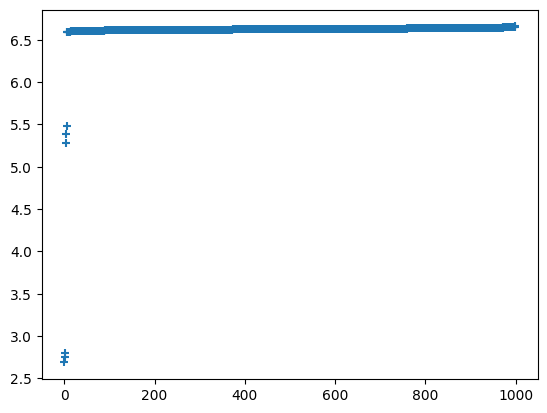

In [134]:
import numpy as np
from scipy.stats import entropy

def create_orthonormal_matrix(n, high_conc=3, med_conc=3):
    # Total special columns
    special_cols = high_conc + med_conc
    
    # Much more distinct concentration levels
    high_density = max(1, n // 50)     # ~2% non-zero elements
    med_density = max(1, n // 4)       # ~12.5% non-zero elements
    
    # Initialize matrix
    concentrated = np.zeros((n, n))
    
    # Generate high concentration columns (very sparse)
    for i in range(high_conc):
        v = np.zeros(n)
        positions = np.random.choice(n, high_density, replace=False)
        v[positions] = np.random.normal(0, 1, high_density)
        concentrated[:, i] = v
    
    # Generate medium concentration columns
    for i in range(high_conc, high_conc + med_conc):
        v = np.zeros(n)
        positions = np.random.choice(n, med_density, replace=False)
        v[positions] = np.random.normal(0, 1, med_density)
        concentrated[:, i] = v
    
    # The rest with low concentration
    remaining = np.random.normal(0, 1, (n, n-special_cols))
    concentrated[:, special_cols:] = remaining
    Q, _ = np.linalg.qr(concentrated[:, :], mode='complete')    
    return Q

# Example usage
np.random.seed(10)
n = 1000
Q = create_orthonormal_matrix(n, high_conc=3, med_conc=3)

# Calculate entropy for each column
entropies = []
for i in range(n):
    col = Q[:, i]
    prob_dist = np.abs(col)
    col_entropy = entropy(prob_dist)  # higher entropy means more spread out, lower means more concentrated)
    entropies.append(col_entropy)

# Reorder Q by entropy
new_order = np.argsort(entropies)
Q_reordered = Q[:, new_order]

# Create sorted list of entropies
sorted_entropies = [entropies[i] for i in new_order]
print(sorted_entropies[:10], sorted_entropies[-1])
import matplotlib.pyplot as plt
plt.scatter(np.arange(len(sorted_entropies)), sorted_entropies, marker='+')
plt.show()

In [378]:
import numpy as np
np.random.seed(10)

n = 1000
eps = 1e-2
a = 1/3
k = 100
b = 2/3 - eps

norm_rest_sq = (1-a-b)

u = np.zeros(n)
u[0] = np.sqrt(a)
# u[1] = b
u[1:k] = np.random.randn(k-1)
u[1:k] /= np.linalg.norm(u[1:k])
u[1:k] *= np.sqrt(b) # norm sqrt(b)
u[k:] = np.random.randn(n-k)
u[k:] /= np.linalg.norm(u[k:])
u[k:] *= np.sqrt(norm_rest_sq) 
# u[k:] = np.ones(n-k) * c #np.random.randn(n-2)
print(np.linalg.norm(u))
# u /= np.linalg.norm(u)


Q = np.random.randn(n, n)
Q[:,0] = u
Q, _ = np.linalg.qr(Q)
Q[:10, :2], Q[-10:, :2], np.linalg.norm(Q[:100, 0])**2, np.linalg.norm(Q[100:, 0])**2, np.linalg.norm(Q[:100, 1])**2, np.linalg.norm(Q[100:, 1])**2, np.max(np.abs(Q[:, 0])), np.sqrt(a)

1.0


(array([[-5.77350269e-01,  2.62596271e-02],
        [-1.13535792e-01, -4.67550920e-02],
        [-6.09872243e-02,  5.43890684e-03],
        [ 1.31766314e-01, -6.28460227e-02],
        [ 7.14836804e-04,  2.03480441e-02],
        [-5.29773106e-02,  1.83510339e-02],
        [ 6.13970509e-02,  4.40781349e-04],
        [-2.26384603e-02, -3.09374099e-02],
        [-9.25523261e-03, -2.79666486e-03],
        [-3.65902634e-04, -7.13146037e-02]]),
 array([[-0.00110658, -0.02819368],
        [-0.00139582, -0.03605316],
        [ 0.00674392,  0.07282367],
        [ 0.00121563,  0.01505265],
        [-0.00024836, -0.01758607],
        [ 0.0005708 ,  0.01972528],
        [ 0.0036106 , -0.00775582],
        [ 0.00118116,  0.04346535],
        [-0.00512825,  0.04342575],
        [ 0.001389  , -0.04844965]]),
 0.9900000000000002,
 0.01000000000000012,
 0.09818558198003015,
 0.9018144180199699,
 0.5773502691896257,
 0.5773502691896257)

In [377]:
np.max(Q[0, 0])

-0.5773502691896257

In [375]:
import numpy as np
n = 1000
# eps = 1e-2
a = 1/np.sqrt(4)
k = 900
b = a/(10*k)
c = np.sqrt((1-a**2-(k-1)*b**2)/(n-k))

u = np.zeros(n)
u[0] = a
# u[1] = b
u[1:k] = b * np.ones(k-1)
u[k:] = np.ones(n-k) * c #np.random.randn(n-2)
print(np.linalg.norm(u))
# u /= np.linalg.norm(u)

v = np.zeros(n)
v[0] = a
# v[1:] = np.ones(n-1) * 10 * eps
v[1:] = np.random.randn(n-1)

# Get v perp to u[1:] first, then do the rest
v_perp = v[1:] - np.dot(u[1:], v[1:]) * u[1:]  / np.linalg.norm(u[1:])**2
v_perp = v_perp * np.sqrt(1-(a**2 / np.linalg.norm(u[1:]))**2-a**2) / np.linalg.norm(v_perp)
v_ = np.zeros(n)
v_[0] = a
v_[1:] = -a**2 * u[1:] / np.linalg.norm(u[1:])**2 + v_perp
print(np.dot(u,v_), np.linalg.norm(v_))

Q = np.random.randn(n, n)
Q[:,0] = v_
Q[:,1] = u
Q, _ = np.linalg.qr(Q)
Q[:10, :2], Q[-10:, :2]

0.9999999999999996
-1.169546390043361e-16 1.0


(array([[-5.00000000e-01,  5.00000000e-01],
        [-3.60977538e-02,  5.55555556e-05],
        [-3.66692260e-02,  5.55555556e-05],
        [-1.66877215e-02,  5.55555556e-05],
        [-8.75919876e-04,  5.55555556e-05],
        [-1.95203516e-02,  5.55555556e-05],
        [ 2.19385235e-02,  5.55555556e-05],
        [ 5.15608728e-03,  5.55555556e-05],
        [ 1.74973005e-02,  5.55555556e-05],
        [-2.52890088e-02,  5.55555556e-05]]),
 array([[ 0.01703425,  0.08660238],
        [ 0.05307451,  0.08660238],
        [ 0.02268749,  0.08660238],
        [ 0.02611543,  0.08660238],
        [ 0.01486572,  0.08660238],
        [-0.00320873,  0.08660238],
        [ 0.03673185,  0.08660238],
        [-0.01290382,  0.08660238],
        [ 0.01731582,  0.08660238],
        [ 0.06471646,  0.08660238]]))

In [332]:
np.linalg.norm(Q[-10:, 0]), np.linalg.norm(Q[-10:, 1]), Q[-10:, 0], Q[-10:, 1]

(0.12231482166178564,
 0.27386077216509896,
 array([-0.0105667 ,  0.0770965 ,  0.01616546,  0.00751116,  0.0205759 ,
         0.02287182,  0.03582198,  0.01439309,  0.04706449,  0.06273533]),
 array([0.08660238, 0.08660238, 0.08660238, 0.08660238, 0.08660238,
        0.08660238, 0.08660238, 0.08660238, 0.08660238, 0.08660238]))

In [360]:
import numpy as np
np.random.seed(10)

n = 1000
# eps = 1e-2
a = 1/np.sqrt(3)
k = 100
b = 10*a/(k)
norm_b = np.sqrt((k-1)*b**2)
norm_rest = np.sqrt((1-a**2-(k-1)*b**2))

u = np.zeros(n)
u[0] = a
# u[1] = b
u[1:k] = np.random.randn(k-1)
u[1:k] /= np.linalg.norm(u[1:k])
u[1:k] *= norm_b
u[k:] = norm_rest * np.random.randn(n-k)
u[k:] /= np.linalg.norm(u[k:])
u[k:] *= norm_rest
# u[k:] = np.ones(n-k) * c #np.random.randn(n-2)
print(np.linalg.norm(u))
# u /= np.linalg.norm(u)

v = np.zeros(n)
v[0] = a
# v[1:] = np.ones(n-1) * 10 * eps
v[1:] = np.random.randn(n-1)

# Get v perp to u[1:] first, then do the rest
v_perp = v[1:] - np.dot(u[1:], v[1:]) * u[1:]  / np.linalg.norm(u[1:])**2
v_perp = v_perp * np.sqrt(1-(a**2 / np.linalg.norm(u[1:]))**2-a**2) / np.linalg.norm(v_perp)
v_ = np.zeros(n)
v_[0] = a
v_[1:] = -a**2 * u[1:] / np.linalg.norm(u[1:])**2 + v_perp
print(np.dot(u,v_), np.linalg.norm(v_))

Q = np.random.randn(n, n)
Q[:,0] = v_
Q[:,1] = u
Q, _ = np.linalg.qr(Q)
Q[:10, :2], Q[-10:, :2]

1.0
1.224761545218788e-16 1.0000000000000002


(array([[-5.77350269e-01, -5.77350269e-01],
        [ 2.95925033e-02, -8.04854317e-02],
        [-1.04383619e-02, -4.32337943e-02],
        [-4.79442100e-02,  9.34090345e-02],
        [ 2.86552364e-03,  5.06747236e-04],
        [-5.93389947e-03, -3.75555729e-02],
        [-5.05217976e-02,  4.35243201e-02],
        [-6.61800719e-03, -1.60483863e-02],
        [ 3.09860223e-02, -6.56102696e-03],
        [-1.18412654e-02, -2.59388084e-04]]),
 array([[ 0.01660101, -0.00642073],
        [ 0.02051032, -0.00809899],
        [-0.03347224,  0.03913024],
        [-0.01048381,  0.00705346],
        [ 0.03698123, -0.00144108],
        [ 0.0275807 ,  0.00331196],
        [-0.0231549 ,  0.02094979],
        [-0.01802869,  0.00685345],
        [-0.00968948, -0.02975563],
        [-0.01280501,  0.00805942]]))

In [361]:
 np.linalg.norm(v_[:100])**2, np.linalg.norm(u[:100])**2, np.linalg.norm(v_[100:])**2, np.linalg.norm(u[100:])**2, np.linalg.norm(v_[-100:]), np.linalg.norm(u[-100:]),

(0.46861233043186046,
 0.6633333333333336,
 0.53138766956814,
 0.3366666666666666,
 0.22606173041179076,
 0.174197141487616)

In [275]:
Q[:5,-3:]

array([[-0.01903794,  0.00221945,  0.01382704],
       [-0.03409479,  0.00397478,  0.02476265],
       [ 0.04243967,  0.0190433 ,  0.03149628],
       [ 0.02783319,  0.01428036, -0.01254766],
       [-0.03383287, -0.0079244 ,  0.01573652]])

In [276]:
temp = Q[:,0].copy()
Q[:,0] = Q[:, 1]
Q[:,1] = temp
temp = Q[:,1].copy()
Q[:,1] = Q[:, -1]
Q[:,-1] = temp
Q[:5, :3], Q[:5, -3:]

(array([[-0.63245553,  0.01382704, -0.009337  ],
        [-0.03162278,  0.02476265, -0.01672151],
        [-0.02449899,  0.03149628, -0.07273527],
        [-0.02449899, -0.01254766,  0.01884248],
        [-0.02449899,  0.01573652, -0.01287517]]),
 array([[-0.01903794,  0.00221945, -0.63245553],
        [-0.03409479,  0.00397478,  0.59795079],
        [ 0.04243967,  0.0190433 ,  0.01558656],
        [ 0.02783319,  0.01428036,  0.01558656],
        [-0.03383287, -0.0079244 ,  0.01558656]]))

In [256]:
np.linalg.norm(-a**2 * u[1:] / np.linalg.norm(u[1:])**2)

0.5163977794943224

In [257]:
v_[:10], u[:10]

(array([ 0.63245553, -0.59795079, -0.01558656, -0.01558656, -0.01558656,
        -0.01558656, -0.01558656, -0.01558656, -0.01558656, -0.01558656]),
 array([0.63245553, 0.03162278, 0.02449899, 0.02449899, 0.02449899,
        0.02449899, 0.02449899, 0.02449899, 0.02449899, 0.02449899]))

In [227]:
np.dot(v[1:] - np.dot(u[1:], v[1:]) * u[1:] / np.linalg.norm(u[1:])**2, u[1:])

7.738118551816526e-16

In [228]:
np.dot(u,v_), np.linalg.norm(u), np.linalg.norm(v_)

(9.132575841158455e-15, 1.0000000000000002, 0.9999999999999947)

array([[-0.63245553, -0.63245553],
       [ 0.59795079, -0.03162278],
       [ 0.01558656, -0.02449899],
       [ 0.01558656, -0.02449899],
       [ 0.01558656, -0.02449899]])

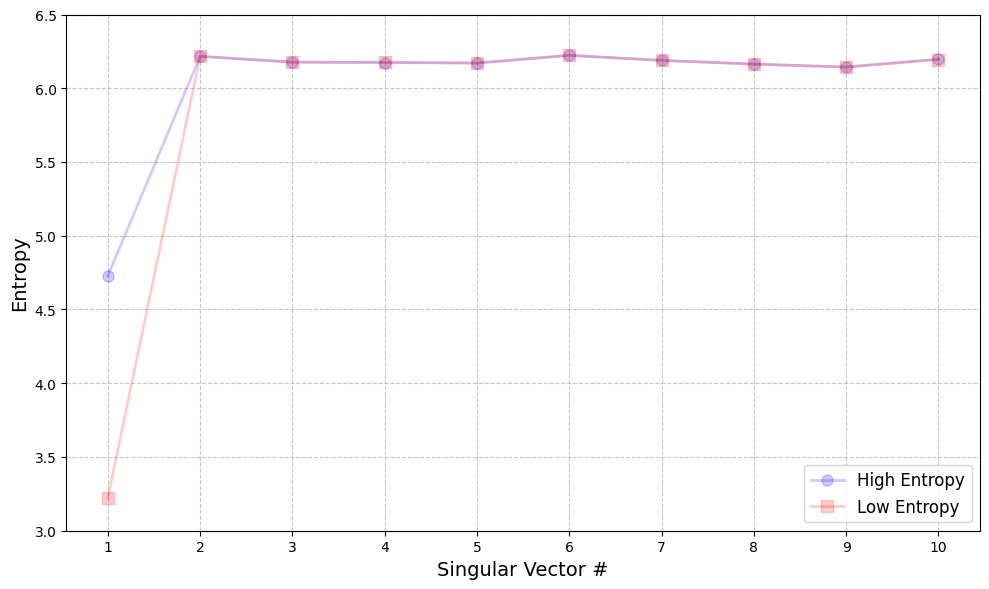

In [381]:
import matplotlib.pyplot as plt
import numpy as np

# Data
high_entropy = [4.727938762249039, 6.215867201352276, 6.17677471047155, 6.174025154434884, 
               6.170217073618721, 6.223322063769944, 6.188614977030353, 6.163025942815994, 
               6.143707920542948, 6.197841239209662]

low_entropy = [3.2231983279204552, 6.217551796319087, 6.176616683952016, 6.176502482619757, 
              6.171213798623388, 6.222383342353607, 6.189350189839969, 6.164291359263114, 
              6.143672048058207, 6.194254996813946]

# X-axis values (Singular vector numbers)
x = np.arange(1, len(high_entropy) + 1)

# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot both datasets
plt.plot(x, high_entropy, 'o-', color='blue', linewidth=2, markersize=8, label='High Entropy', alpha=0.2)
plt.plot(x, low_entropy, 's-', color='red', linewidth=2, markersize=8, label='Low Entropy', alpha=0.2)

# Add labels and title
plt.xlabel('Singular Vector #', fontsize=14)
plt.ylabel('Entropy', fontsize=14)
# plt.title('Entropy Comparison', fontsize=16)

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Set y-axis range to better show the difference
plt.ylim(3.0, 6.5)

# Add legend
plt.legend(fontsize=12)

# Add ticks for each singular vector
plt.xticks(x)

# Tight layout
plt.tight_layout()

# Show plot
plt.show()

# Uncomment to save the figure
# plt.savefig('entropy_comparison.png', dpi=300, bbox_inches='tight')

In [647]:
import numpy as np

def solve_coefficients(v1, v2, u1, u2):
    # Calculate the dot products
    v1_dot_u1 = np.dot(v1, u1)
    v1_dot_u2 = np.dot(v1, u2)
    v2_dot_u1 = np.dot(v2, u1)
    v2_dot_u2 = np.dot(v2, u2)
    
    # Calculate a and b
    a = v1_dot_u1 - v2_dot_u1
    b = v2_dot_u2 - v1_dot_u2
    
    # Choose c2 = 1 (arbitrary choice)
    c2 = 1.0
    
    # Calculate c1 based on c2
    c1 = (b / a) * c2
    
    # Calculate lambda
    lambda_val = c1 * v1_dot_u1 + c2 * v1_dot_u2
    
    return c1, c2, lambda_val

# Example usage with some test vectors
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
u1 = np.array([7, 8, 9])
u2 = np.array([10, 11, 12])

c1, c2, lambda_val = solve_coefficients(v1, v2, u1, u2)

print(f"c1 = {c1}")
print(f"c2 = {c2}")
print(f"λ = {lambda_val}")

# Verify that the solution satisfies the original equations
eq1 = c1 * np.dot(v1, u1) + c2 * np.dot(v1, u2)
eq2 = c1 * np.dot(v2, u1) + c2 * np.dot(v2, u2)

print(f"Equation 1 = {eq1}")
print(f"Equation 2 = {eq2}")
print(f"Are equations equal? {np.isclose(eq1, eq2)}")

c1 = -1.375
c2 = 1.0
λ = -0.75
Equation 1 = -0.75
Equation 2 = -0.75
Are equations equal? True


Symbolic verification:
Determinant equation: (a1*lambda - alpha_1)*(b2*lambda - beta_2) - (a2*lambda - alpha_2)*(b1*lambda - beta_1)
Example with random values:
v1 = [0.8734294  0.96854066 0.86919454]
v2 = [0.53085569 0.23272833 0.0113988 ]
u1 = [0.43046882 0.40235136 0.52267467]
u2 = [0.4783918  0.55535647 0.54338602]
a1 = 0.760895575602929, a2 = 0.7123745740820913
b1 = 0.6196820961034396, b2 = 0.4260917704761922
α₁ = 1.21998374646696, β₁ = 1.4280349474425338
α₂ = 0.3281132477881843, β₂ = 0.3893981420403037
Quadratic coefficients: A=-0.11723442632183201, B=0.4045053346966529, C=0.006502219633204409
Discriminant: 0.16667370175212026

For λ = -0.016000299480371596:
  Solution: c1 = 0.7593532198297805, c2 = -0.6506786361439454
  Constraint check: c1² + c2² = 0.9999999999999999
  Equation 1 check: LHS = -0.016000299480371086, λ = -0.016000299480371596, diff = 5.100087019371813e-16
  Equation 2 check: LHS = -0.016000299480371346, λ = -0.016000299480371596, diff = 2.498001805406602e-16
  Al

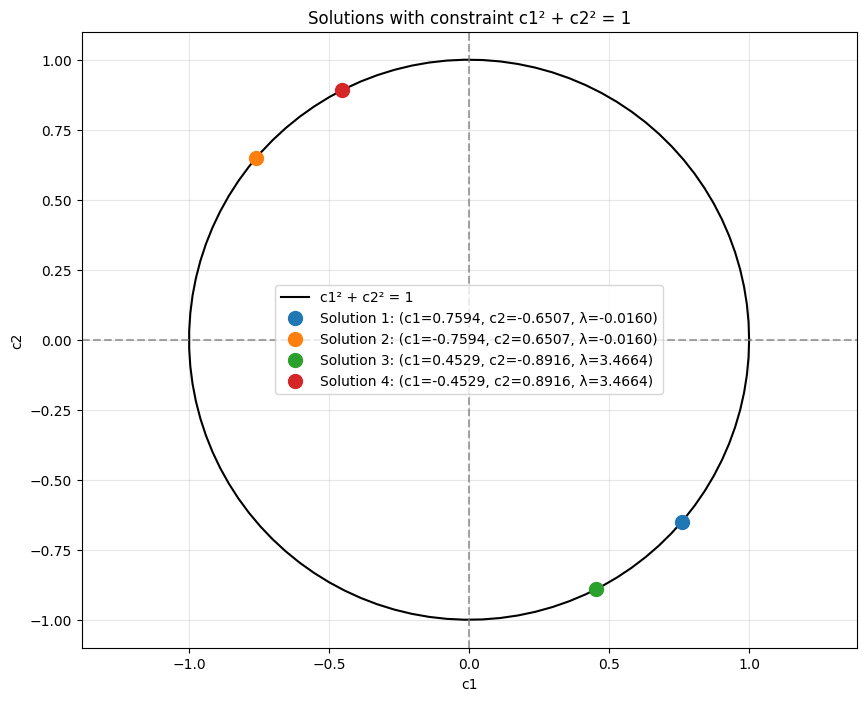

In [674]:
import numpy as np
from sympy import symbols, solve, Eq, simplify
import matplotlib.pyplot as plt

def solve_system_numerically(v1, v2, u1, u2, a1, a2, b1, b2):
    """
    Solve the system of equations:
    (c1 vj^T u1 + c2 vj^T u2) / (c1 aj + c2 bj) = λ, for j = 1,2
    with constraint c1² + c2² = 1
    
    Returns computed values for c1, c2, and λ
    """
    # Calculate dot products
    alpha_1 = np.dot(v1, u1)
    beta_1 = np.dot(v1, u2)
    alpha_2 = np.dot(v2, u1)
    beta_2 = np.dot(v2, u2)
    
    print(f"α₁ = {alpha_1}, β₁ = {beta_1}")
    print(f"α₂ = {alpha_2}, β₂ = {beta_2}")
    
    # Coefficients for quadratic equation in λ
    A = a1*b2 - b1*a2
    B = beta_1*a2 + b1*alpha_2 - alpha_1*b2 - a1*beta_2
    C = alpha_1*beta_2 - beta_1*alpha_2
    
    print(f"Quadratic coefficients: A={A}, B={B}, C={C}")
    
    # Solve for λ using the quadratic formula
    if abs(A) < 1e-10:  # A is approximately zero
        if abs(B) < 1e-10:  # B is also approximately zero
            print("Degenerate case: both A and B are approximately zero")
            return None
        lambda_values = [-C/B]
    else:
        discriminant = B**2 - 4*A*C
        print(f"Discriminant: {discriminant}")
        
        if discriminant < 0:
            print("No real solutions (complex λ values)")
            return None
        
        lambda_1 = (-B + np.sqrt(discriminant)) / (2*A)
        lambda_2 = (-B - np.sqrt(discriminant)) / (2*A)
        lambda_values = [lambda_1, lambda_2]
    
    solutions = []
    for lambda_val in lambda_values:
        print(f"\nFor λ = {lambda_val}:")
        
        # Check denominators to avoid division by zero
        denom1 = beta_1 - lambda_val*b1
        if abs(denom1) < 1e-10:
            # Use the second equation instead
            denom2 = beta_2 - lambda_val*b2
            if abs(denom2) < 1e-10:
                print("  Cannot solve: denominators too close to zero")
                continue
            
            factor = (alpha_2 - lambda_val*a2) / denom2
            c1_squared = 1 / (1 + factor**2)
            c1 = np.sqrt(c1_squared)
            c2 = -factor * c1
        else:
            factor = (alpha_1 - lambda_val*a1) / denom1
            c1_squared = 1 / (1 + factor**2)
            c1 = np.sqrt(c1_squared)
            c2 = -factor * c1
        
        # Verify: Check both original equations
        eq1_lhs = (c1 * alpha_1 + c2 * beta_1) / (c1 * a1 + c2 * b1)
        eq2_lhs = (c1 * alpha_2 + c2 * beta_2) / (c1 * a2 + c2 * b2)
        
        print(f"  Solution: c1 = {c1}, c2 = {c2}")
        print(f"  Constraint check: c1² + c2² = {c1**2 + c2**2}")
        print(f"  Equation 1 check: LHS = {eq1_lhs}, λ = {lambda_val}, diff = {abs(eq1_lhs - lambda_val)}")
        print(f"  Equation 2 check: LHS = {eq2_lhs}, λ = {lambda_val}, diff = {abs(eq2_lhs - lambda_val)}")
        
        solutions.append((c1, c2, lambda_val))
        
        # Consider negative c1 as well
        c1 = -c1
        c2 = -c2  # c2 flips sign as well to maintain the same ratio
        
        eq1_lhs = (c1 * alpha_1 + c2 * beta_1) / (c1 * a1 + c2 * b1)
        eq2_lhs = (c1 * alpha_2 + c2 * beta_2) / (c1 * a2 + c2 * b2)
        
        print(f"  Alternative solution: c1 = {c1}, c2 = {c2}")
        print(f"  Constraint check: c1² + c2² = {c1**2 + c2**2}")
        print(f"  Equation 1 check: LHS = {eq1_lhs}, λ = {lambda_val}, diff = {abs(eq1_lhs - lambda_val)}")
        print(f"  Equation 2 check: LHS = {eq2_lhs}, λ = {lambda_val}, diff = {abs(eq2_lhs - lambda_val)}")
        
        solutions.append((c1, c2, lambda_val))
    
    return solutions

def verify_solution_symbolically():
    """
    Verify the solution approach symbolically using SymPy
    """
    # Define symbols
    c1, c2 = symbols('c1 c2')
    lambda_val = symbols('lambda')
    alpha_1, beta_1, alpha_2, beta_2 = symbols('alpha_1 beta_1 alpha_2 beta_2')
    a1, b1, a2, b2 = symbols('a1 b1 a2 b2')
    
    # Define the equations
    eq1 = Eq((c1 * alpha_1 + c2 * beta_1) / (c1 * a1 + c2 * b1), lambda_val)
    eq2 = Eq((c1 * alpha_2 + c2 * beta_2) / (c1 * a2 + c2 * b2), lambda_val)
    
    # Create the determinant equation
    det_eq = (alpha_1 - lambda_val*a1)*(beta_2 - lambda_val*b2) - (beta_1 - lambda_val*b1)*(alpha_2 - lambda_val*a2)
    det_eq_expanded = simplify(det_eq)
    
    print("Symbolic verification:")
    print(f"Determinant equation: {det_eq_expanded}")
    
    # This should simplify to a quadratic in lambda_val with the coefficients we identified

# Test with example values
def run_example():
    print("Example with random values:")
    np.random.seed(8)  # For reproducibility
    
    # Generate random vectors
    v1 = np.random.rand(3)
    v2 = np.random.rand(3)
    u1 = np.random.rand(3)
    u2 = np.random.rand(3)
    
    # Generate random coefficients
    a1, a2 = np.random.rand(2)
    b1, b2 = np.random.rand(2)
    
    print(f"v1 = {v1}")
    print(f"v2 = {v2}")
    print(f"u1 = {u1}")
    print(f"u2 = {u2}")
    print(f"a1 = {a1}, a2 = {a2}")
    print(f"b1 = {b1}, b2 = {b2}")
    
    # Solve the system
    solutions = solve_system_numerically(v1, v2, u1, u2, a1, a2, b1, b2)
    
    # Visualize the solutions
    if solutions:
        theta = np.linspace(0, 2*np.pi, 100)
        x = np.cos(theta)  # c1 values on unit circle
        y = np.sin(theta)  # c2 values on unit circle
        
        plt.figure(figsize=(10, 8))
        plt.plot(x, y, 'k-', label='c1² + c2² = 1')
        
        for i, (c1, c2, lambda_val) in enumerate(solutions):
            plt.plot(c1, c2, 'o', markersize=10, label=f'Solution {i+1}: (c1={c1:.4f}, c2={c2:.4f}, λ={lambda_val:.4f})')
        
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
        plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
        plt.grid(True, alpha=0.3)
        plt.title('Solutions with constraint c1² + c2² = 1')
        plt.xlabel('c1')
        plt.ylabel('c2')
        plt.axis('equal')
        plt.legend()
        plt.show()

# Run symbolic verification
verify_solution_symbolically()

# Run numerical example
run_example()

In [675]:
np.random.seed(10)
V = np.random.randn(5,3)
V, _ = np.linalg.qr(V)
S = np.array([5,3,1])
A = V @ np.diag(S) @ V.T

In [676]:
A[2, :] @ V[:,0] / V[2,0]

4.999999999999997

In [776]:
theta = np.pi / 3
eps = 0.1
u1 = np.cos(theta)*V[:,0] + np.sin(theta)*V[:,1]
u2 = -np.sin(theta)*V[:,0] + np.cos(theta)*V[:,1] + eps * np.random.randn(5)
u2 = u2 - np.dot(u1, u2) * u1
print(np.linalg.norm(u2))
u2 = u2 / np.linalg.norm(u2)
u1, u2, np.dot(u1, u2)

0.910766463966443


(array([-0.84557936, -0.36419923, -0.14848517, -0.20018068, -0.30039028]),
 array([ 0.45262621, -0.29318604,  0.12318862, -0.30894905, -0.77365787]),
 6.592548097397981e-17)

In [777]:
V[:, :2]

array([[-0.794991  , -0.51740267],
       [ 0.00500537, -0.4234309 ],
       [-0.15851717, -0.07993597],
       [ 0.10424077, -0.29133218],
       [ 0.57616874, -0.679512  ]])

In [653]:
# solve_coefficients(A[1,:], A[2,:], u1, u2)

(-0.7818659899581056, 1.0, -0.21801052259662057)

In [756]:
solve_system_numerically(A[1,:], A[2,:], u1, u2, u1[1], u1[2], u2[1], u2[2])

α₁ = -1.0875923192104293, β₁ = -0.6568202446193879
α₂ = -0.603972666210852, β₂ = 0.5664955150860198
Quadratic coefficients: A=-0.06752117636258315, B=0.5401694109006652, C=-1.0128176454387467
Discriminant: 0.018236437029548358

For λ = 2.999999999999997:
  Solution: c1 = 0.8660254037844795, c2 = 0.4999999999999294
  Constraint check: c1² + c2² = 1.0
  Equation 1 check: LHS = 2.9999999999999973, λ = 2.999999999999997, diff = 4.440892098500626e-16
  Equation 2 check: LHS = 3.000000000000324, λ = 2.999999999999997, diff = 3.2729374765949615e-13
  Alternative solution: c1 = -0.8660254037844795, c2 = -0.4999999999999294
  Constraint check: c1² + c2² = 1.0
  Equation 1 check: LHS = 2.9999999999999973, λ = 2.999999999999997, diff = 4.440892098500626e-16
  Equation 2 check: LHS = 3.000000000000324, λ = 2.999999999999997, diff = 3.2729374765949615e-13

For λ = 5.0000000000000036:
  Solution: c1 = 0.49999999999999983, c2 = -0.8660254037844387
  Constraint check: c1² + c2² = 1.0
  Equation 1 chec

[(0.8660254037844795, 0.4999999999999294, 2.999999999999997),
 (-0.8660254037844795, -0.4999999999999294, 2.999999999999997),
 (0.49999999999999983, -0.8660254037844387, 5.0000000000000036),
 (-0.49999999999999983, 0.8660254037844387, 5.0000000000000036)]

In [757]:
V_tilde = np.concatenate([u1.reshape(-1,1), u2.reshape(-1,1)], axis=1)
A[1:3, :].shape, V_tilde.shape
# sorted_idx = np.argsort(S_)
# S_ = S_[sorted_idx]
# V_coeffs = V_coeffs[sorted_idx, :]

((2, 5), (5, 2))

In [758]:
V_tilde[1:3,:]

array([[-0.36419923, -0.21605023],
       [-0.14848517,  0.09731191]])

In [779]:
import scipy
S_, V_coeffs = scipy.linalg.eig(A[1:3, :] @ V_tilde, V_tilde[1:3,:])
sorted_idx = np.argsort(S_)[::-1]
S_ = S_[sorted_idx]
V_coeffs = V_coeffs[:, sorted_idx]
S_, V_coeffs

(array([5.+0.j, 3.+0.j]),
 array([[-0.5      ,  0.8660254],
        [ 0.8660254,  0.5      ]]))

In [780]:
V_tilde @ V_coeffs, V[:, :2]

(array([[ 0.794991  , -0.51740267],
        [-0.00500537, -0.4234309 ],
        [ 0.15851717, -0.07993597],
        [-0.10424077, -0.29133218],
        [-0.57616874, -0.679512  ]]),
 array([[-0.794991  , -0.51740267],
        [ 0.00500537, -0.4234309 ],
        [-0.15851717, -0.07993597],
        [ 0.10424077, -0.29133218],
        [ 0.57616874, -0.679512  ]]))

In [781]:
(V_tilde @ V_coeffs).T @ V[:, :2]

array([[-1.00000000e+00,  1.36555781e-15],
       [-1.51407253e-16,  1.00000000e+00]])

In [782]:
V_tilde @ V_coeffs, V[:, :2]

(array([[ 0.794991  , -0.51740267],
        [-0.00500537, -0.4234309 ],
        [ 0.15851717, -0.07993597],
        [-0.10424077, -0.29133218],
        [-0.57616874, -0.679512  ]]),
 array([[-0.794991  , -0.51740267],
        [ 0.00500537, -0.4234309 ],
        [-0.15851717, -0.07993597],
        [ 0.10424077, -0.29133218],
        [ 0.57616874, -0.679512  ]]))

In [656]:
ratio = ( A[1,:] @ u1 - A[2,:] @ u1) / (A[2,:] @ u2 - A[1,:] @ u2)
A[2,:] @ u2 - A[1,:] @ u2, A[1,:] @ u1 - A[2,:] @ u1, ratio

(0.7377360235129637, -0.9435581454981736, -1.278991557176675)

In [662]:
c2 = 1 / np.sqrt(ratio**2 + 1)
c1 = ratio * c2
c1, c2, c1**2 + c2**2

(-0.7877888909784432, 0.6159453411228586, 1.0)

In [660]:
c1 * u1 + c2*u2, V[:,0], V[:,1]

(array([ 0.01727557,  0.08363553, -0.00111488,  0.06822851,  0.19444146]),
 array([-0.794991  ,  0.00500537, -0.15851717,  0.10424077,  0.57616874]),
 array([-0.51740267, -0.4234309 , -0.07993597, -0.29133218, -0.679512  ]))

In [661]:
np.linalg.norm(c1 * u1 + c2*u2)

0.2230632237013994

In [665]:
c1 * A[1,:] @ u1 + c2 * A[1,:] @ u2, c1 * A[2,:] @ u1 + c2 * A[2,:] @ u2

(0.2519677781382629, -0.036951780216106234)

In [ ]:
A[1,:] @ u1

Matrix A:
[[5 3 8]
 [9 9 7]
 [7 3 7]]

Matrix B:
[[2 1 3]
 [1 3 2]
 [3 2 1]]

Eigenvalues (λ):
[2.83974999+0.j         1.02456945+1.13924622j 1.02456945-1.13924622j]

Eigenvectors (before normalization):
[[-0.17147136+0.j          0.65672044-0.082304j    0.65672044+0.082304j  ]
 [ 0.85558429+0.j         -0.58141066-0.36478762j -0.58141066+0.36478762j]
 [ 0.48843945+0.j         -0.19640654+0.22860537j -0.19640654-0.22860537j]]

Normalized Eigenvectors (c1, c2, c3):
[[-0.17147136+0.j          0.65672044-0.082304j    0.65672044+0.082304j  ]
 [ 0.85558429+0.j         -0.58141066-0.36478762j -0.58141066+0.36478762j]
 [ 0.48843945+0.j         -0.19640654+0.22860537j -0.19640654-0.22860537j]]

Verification of solutions:
Solution 1: λ = 2.8397+0.0000j, c = [-0.1715+0.0000j, 0.8556+0.0000j, 0.4884+0.0000j]
  Equation 1: 2.8397+0.0000j ≈ 2.8397+0.0000j
  Equation 2: 2.8397+0.0000j ≈ 2.8397+0.0000j
  Equation 3: 2.8397+0.0000j ≈ 2.8397+0.0000j
  Norm of c: 1.0000 (should be 1.0)

Solution 2: λ = 

/home/ttran02/.conda/envs/mcts/lib/python3.10/site-packages/mpl_toolkits/mplot3d/axes3d.py:3034: ComplexWarning: Casting complex values to real discards the imaginary part
  UVW = np.column_stack(input_args[3:]).astype(float)


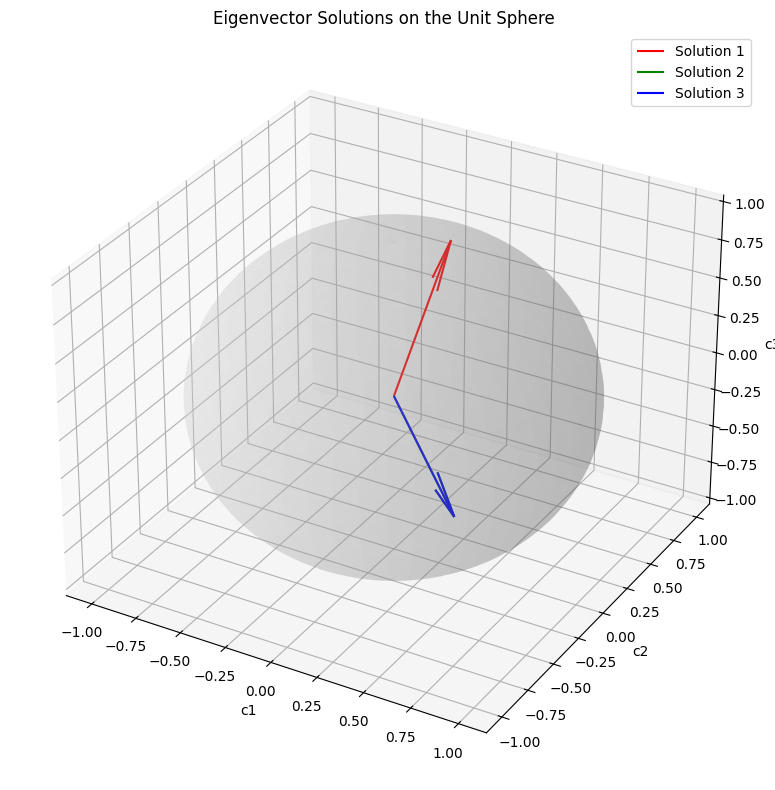

In [673]:
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt

# Let's create an example with n=3 (three variables c1, c2, c3)
# We'll define the matrices A and B

# Matrix A with elements a_jk = v_j^T u_k
# Let's create some example vectors v_j and u_k
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 1])
v3 = np.array([2, 1, 3])

u1 = np.array([2, 0, 1])
u2 = np.array([1, 1, 0])
u3 = np.array([0, 1, 2])

# Calculate the elements of matrix A as dot products
a11 = np.dot(v1, u1)  # v1^T u1
a12 = np.dot(v1, u2)  # v1^T u2
a13 = np.dot(v1, u3)  # v1^T u3
a21 = np.dot(v2, u1)  # v2^T u1
a22 = np.dot(v2, u2)  # v2^T u2
a23 = np.dot(v2, u3)  # v2^T u3
a31 = np.dot(v3, u1)  # v3^T u1
a32 = np.dot(v3, u2)  # v3^T u2
a33 = np.dot(v3, u3)  # v3^T u3

# Construct matrix A
A = np.array([
    [a11, a12, a13],
    [a21, a22, a23],
    [a31, a32, a33]
])

# Matrix B with denominator coefficients
# For this example, let's define these directly
B = np.array([
    [2, 1, 3],   # [a1, b1, c1]
    [1, 3, 2],   # [a2, b2, c2]
    [3, 2, 1]    # [a3, b3, c3]
])

print("Matrix A:")
print(A)
print("\nMatrix B:")
print(B)

# Solve the generalized eigenvalue problem Ac = λBc
eigenvalues, eigenvectors = linalg.eig(A, B)

print("\nEigenvalues (λ):")
print(eigenvalues)

print("\nEigenvectors (before normalization):")
print(eigenvectors)

# Normalize the eigenvectors to satisfy c1² + c2² + c3² = 1
normalized_eigenvectors = np.zeros_like(eigenvectors)
for i in range(len(eigenvalues)):
    normalized_eigenvectors[:, i] = eigenvectors[:, i] / np.linalg.norm(eigenvectors[:, i])

print("\nNormalized Eigenvectors (c1, c2, c3):")
print(normalized_eigenvectors)

# Verify that our solutions satisfy the original equations
print("\nVerification of solutions:")
for i, (eigenvalue, eigenvector) in enumerate(zip(eigenvalues, normalized_eigenvectors.T)):
    c1, c2, c3 = eigenvector
    
    # Calculate the left side of equation for j=1, j=2, j=3
    left_side_1 = (c1 * a11 + c2 * a12 + c3 * a13) / (c1 * B[0, 0] + c2 * B[0, 1] + c3 * B[0, 2])
    left_side_2 = (c1 * a21 + c2 * a22 + c3 * a23) / (c1 * B[1, 0] + c2 * B[1, 1] + c3 * B[1, 2])
    left_side_3 = (c1 * a31 + c2 * a32 + c3 * a33) / (c1 * B[2, 0] + c2 * B[2, 1] + c3 * B[2, 2])
    
    print(f"Solution {i+1}: λ = {eigenvalue:.4f}, c = [{c1:.4f}, {c2:.4f}, {c3:.4f}]")
    print(f"  Equation 1: {left_side_1:.4f} ≈ {eigenvalue:.4f}")
    print(f"  Equation 2: {left_side_2:.4f} ≈ {eigenvalue:.4f}")
    print(f"  Equation 3: {left_side_3:.4f} ≈ {eigenvalue:.4f}")
    print(f"  Norm of c: {np.linalg.norm(eigenvector):.4f} (should be 1.0)")
    print()

# Plot the solutions for visualization
plt.figure(figsize=(10, 8))

# Create a 3D plot
ax = plt.axes(projection='3d')

# Plot the unit sphere for reference (c1² + c2² + c3² = 1)
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='lightgray', alpha=0.2)

# Plot the eigenvectors (our solutions)
colors = ['red', 'green', 'blue']
for i, eigenvector in enumerate(normalized_eigenvectors.T):
    c1, c2, c3 = eigenvector
    ax.quiver(0, 0, 0, c1, c2, c3, color=colors[i], label=f'Solution {i+1}')

ax.set_xlabel('c1')
ax.set_ylabel('c2')
ax.set_zlabel('c3')
ax.set_title('Eigenvector Solutions on the Unit Sphere')
ax.legend()

plt.tight_layout()
plt.show()

Solving the generalized eigenvalue problem Ax = λBx
Finding multiple 'most real' solutions with B-orthogonality
------------------------------------------------------------

True (complex) eigenvalues:
λ_1 = 1.333333+2.211083j
λ_2 = 1.333333-2.211083j
λ_3 = 3.000000+1.000000j
λ_4 = 3.000000-1.000000j
λ_5 = 5.000000+0.000000j

Real eigenvalue approximations:
λ_1 = 3.000000, residual = 1.000000e+00
λ_2 = 3.000000, residual = 1.000000e+00
λ_3 = 3.000000, residual = 1.000000e+00

Eigenvectors:
x_1 = [-0. -0. -1. -0. -0.]
x_2 = [-1.10234732e-16  1.11415580e-16  7.07106781e-01 -7.07106781e-01
 -1.96456339e-16]
x_3 = [-2.76531448e-16  5.69501034e-16  7.07106781e-01 -7.07106781e-01
  6.81831055e-17]

B-orthogonality check:
x_i^T B x_j matrix (should be approximately identity):
[[ 1.         -0.70710678 -0.70710678]
 [-0.70710678  1.          1.        ]
 [-0.70710678  1.          1.        ]]

Verification - Ax_i - λ_i Bx_i:
Pair 1: ||Ax_i - λ_i Bx_i|| = 1.000000e+00
Pair 2: ||Ax_i - λ_i Bx_i|

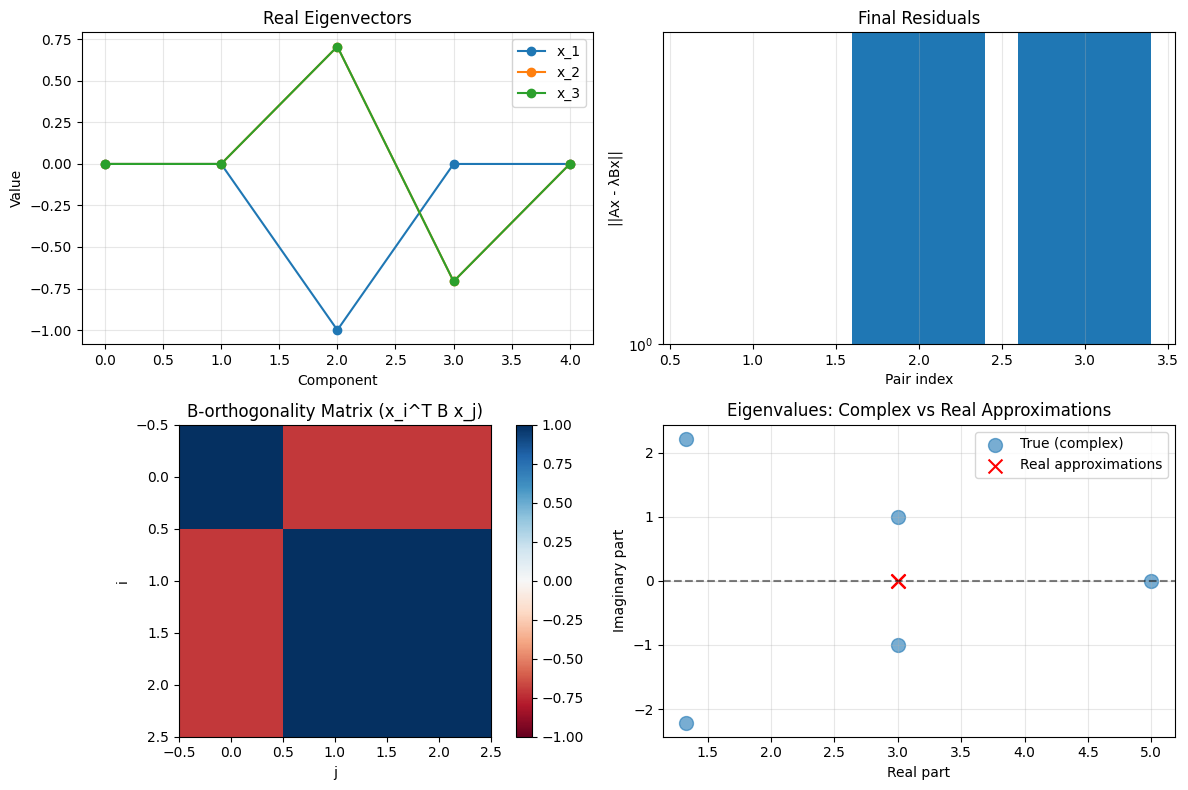

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def find_most_real_solution_with_deflation(A, B, num_pairs=3, max_iterations=100, tolerance=1e-10):
    """
    Find multiple real solutions to Ax = λBx with B-orthogonality constraint.
    
    Parameters:
    A, B: matrices for the generalized eigenvalue problem
    num_pairs: number of (λ, x) pairs to find
    max_iterations: maximum number of iterations
    tolerance: convergence tolerance
    
    Returns:
    eigenvalues: list of real eigenvalues
    eigenvectors: list of real eigenvectors (B-orthogonal)
    residuals: list of final residuals for each pair
    """
    n = A.shape[0]
    
    eigenvalues = []
    eigenvectors = []
    residuals = []
    
    # Store the B-orthogonal vectors
    Q = np.zeros((n, 0))  # Will store eigenvectors in columns
    
    for pair_idx in range(num_pairs):
        # Initialize with a random real vector
        x = np.random.randn(n)
        
        # Apply B-orthogonalization (similar to Gram-Schmidt but with B inner product)
        if Q.shape[1] > 0:
            # Make x B-orthogonal to all previous eigenvectors
            for i in range(Q.shape[1]):
                qi = Q[:, i]
                x = x - (qi.T @ B @ x) / (qi.T @ B @ qi) * qi
        
        # Check if deflation left us with zero vector
        if np.linalg.norm(x) < 1e-14:
            print(f"Deflation produced zero vector at pair {pair_idx}")
            break
            
        x = x / np.linalg.norm(x)
        
        # Compute initial lambda
        denominator = x.T @ B.T @ B @ x
        if np.abs(denominator) > 1e-14:
            lambda_val = (x.T @ A.T @ B @ x) / denominator
        else:
            lambda_val = 1.0
        
        residual_history = []
        
        for i in range(max_iterations):
            # Form the matrix (A - λB)^T (A - λB)
            M = (A - lambda_val * B).T @ (A - lambda_val * B)
            
            # Add B-orthogonality constraint via projection
            if Q.shape[1] > 0:
                # Project out components that would violate B-orthogonality
                for j in range(Q.shape[1]):
                    qj = Q[:, j]
                    normalizer = qj.T @ B @ qj
                    if normalizer > 1e-14:
                        M = M + 1e6 * (B @ qj) @ (qj.T @ B) / normalizer
            
            # Find the eigenvector of M with smallest eigenvalue
            try:
                eigenvalues_M, eigenvectors_M = np.linalg.eigh(M)
                x_new = eigenvectors_M[:, 0]  # eigenvector with smallest eigenvalue
                
                # Ensure consistent direction (avoid sign flipping)
                if np.dot(x, x_new) < 0:
                    x_new = -x_new
                
                x = x_new / np.linalg.norm(x_new)
                
                # Update lambda
                denominator = x.T @ B.T @ B @ x
                if np.abs(denominator) > 1e-14:
                    lambda_val = (x.T @ A.T @ B @ x) / denominator
                
                # Compute residual
                residual = np.linalg.norm(A @ x - lambda_val * B @ x)
                residual_history.append(residual)
                
                # Check convergence
                if residual < tolerance:
                    print(f"Pair {pair_idx+1} converged in {i+1} iterations")
                    break
                    
            except np.linalg.LinAlgError:
                print(f"Linear algebra error at pair {pair_idx+1}, iteration {i+1}")
                break
        
        # Store the solution
        eigenvalues.append(lambda_val)
        eigenvectors.append(x.copy())
        residuals.append(residual_history[-1] if residual_history else float('inf'))
        
        # Add to our B-orthogonal basis
        Q = np.hstack([Q, x.reshape(-1, 1)])
    
    return eigenvalues, eigenvectors, residuals

def verify_b_orthogonality(eigenvectors, B):
    """Verify that eigenvectors are B-orthogonal"""
    n = len(eigenvectors)
    print("\nB-orthogonality check:")
    print("x_i^T B x_j matrix (should be approximately identity):")
    
    ortho_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ortho_matrix[i, j] = eigenvectors[i].T @ B @ eigenvectors[j]
    
    print(ortho_matrix)
    return ortho_matrix

# Example usage
if __name__ == "__main__":
    # Create an example with known complex eigenvalues
    n = 5
    
    # Create matrices that will produce complex eigenvalues
    A = np.array([
        [1, 2, 0, 0, 0],
        [-2, 1, 0, 0, 0],
        [0, 0, 3, 1, 0],
        [0, 0, -1, 3, 0],
        [0, 0, 0, 0, 5]
    ]).astype(float)
    
    B = np.array([
        [1, 0.5, 0, 0, 0],
        [0.5, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1]
    ]).astype(float)  # Non-identity B matrix to test B-orthogonality
    
    print("Solving the generalized eigenvalue problem Ax = λBx")
    print("Finding multiple 'most real' solutions with B-orthogonality")
    print("-" * 60)
    
    # Find the exact (complex) eigenvalues for comparison
    true_eigenvalues = np.linalg.eigvals(np.linalg.solve(B, A))
    print("\nTrue (complex) eigenvalues:")
    for i, eigval in enumerate(true_eigenvalues):
        print(f"λ_{i+1} = {eigval:.6f}")
    
    # Find multiple real solutions
    num_pairs = 3
    eigenvalues, eigenvectors, residuals = find_most_real_solution_with_deflation(A, B, num_pairs)
    
    print("\nReal eigenvalue approximations:")
    for i, (lambda_val, residual) in enumerate(zip(eigenvalues, residuals)):
        print(f"λ_{i+1} = {lambda_val:.6f}, residual = {residual:.6e}")
    
    print("\nEigenvectors:")
    for i, x in enumerate(eigenvectors):
        print(f"x_{i+1} = {x}")
    
    # Verify B-orthogonality
    ortho_matrix = verify_b_orthogonality(eigenvectors, B)
    
    # Verify solutions
    print("\nVerification - Ax_i - λ_i Bx_i:")
    for i, (lambda_val, x) in enumerate(zip(eigenvalues, eigenvectors)):
        residual_vector = A @ x - lambda_val * B @ x
        print(f"Pair {i+1}: ||Ax_i - λ_i Bx_i|| = {np.linalg.norm(residual_vector):.6e}")
    
    # Visualization
    # Plot the eigenvectors
    plt.figure(figsize=(12, 8))
    
    # Plot 1: Eigenvectors
    plt.subplot(2, 2, 1)
    for i, x in enumerate(eigenvectors):
        plt.plot(x, marker='o', label=f'x_{i+1}')
    plt.title('Real Eigenvectors')
    plt.xlabel('Component')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Residuals
    plt.subplot(2, 2, 2)
    plt.bar(range(1, len(residuals)+1), residuals)
    plt.title('Final Residuals')
    plt.xlabel('Pair index')
    plt.ylabel('||Ax - λBx||')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: B-orthogonality matrix
    plt.subplot(2, 2, 3)
    im = plt.imshow(ortho_matrix, cmap='RdBu', vmin=-1, vmax=1)
    plt.colorbar(im)
    plt.title('B-orthogonality Matrix (x_i^T B x_j)')
    plt.xlabel('j')
    plt.ylabel('i')
    
    # Plot 4: Real vs Complex eigenvalues
    plt.subplot(2, 2, 4)
    true_eigenvals_real = [ev.real for ev in true_eigenvalues]
    true_eigenvals_imag = [ev.imag for ev in true_eigenvalues]
    plt.scatter(true_eigenvals_real, true_eigenvals_imag, marker='o', s=100, 
                label='True (complex)', alpha=0.6)
    plt.scatter(eigenvalues, [0]*len(eigenvalues), marker='x', s=100, 
                label='Real approximations', color='red')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.title('Eigenvalues: Complex vs Real Approximations')
    plt.xlabel('Real part')
    plt.ylabel('Imaginary part')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [787]:
residuals

array([], dtype=float64)

In [7]:
import time

start = time.time()
time.sleep(1)
end = time.time()
end-start

1.003828763961792